In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.markers import MarkerStyle
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster import hierarchy
import rasterio as rir
import squarify 
from pypalettes import load_cmap
from highlight_text import fig_text


import os
import zipfile
import tempfile
import requests

In [2]:

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Nimbus Roman"]


#Cretaceous data from Matthews 2016, as provided in Cao et al. 2017 BG Supplement
cretaceouslm = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_76Ma/lm_fig52_81_58_76.00Ma.shp"
)

cretaceousmts = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_76Ma/m_fig52_81_58_76.00Ma.shp"
)

cretaceoussm = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_76Ma/sm_fig52_81_58_76.00Ma.shp"
)

#Jurassic data 
jurassiclm = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_152Ma/lm_fig42_166_146_152.00Ma.shp"
)

jurassicmts = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_152Ma/m_fig42_166_146_152.00Ma.shp"
)

jurassicsm = gpd.read_file(
    "Assets/SHP/Cao_etal_2017_BG_Supplement/bg-2017-94-supplement/PresentDay_Palegeog_Matthews2016_Revised_402-2Ma/Revised_Palegeog_Matthews2016_ModernCoor_402-2Ma_Individually/PresentDay_Paleogeog_Matthews2016_152Ma/sm_fig42_166_146_152.00Ma.shp"
)

#Natural Earth data
ne_rivers_url = (
    "https://naciscdn.org/naturalearth/50m/physical/ne_50m_rivers_lake_centerlines.zip"
)
rivers_temp_dir = tempfile.mkdtemp()
rivers_zip_path = os.path.join(
    rivers_temp_dir, "ne_rivers.zip"
)
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}
response_rivers = requests.get(
    ne_rivers_url, headers=headers, stream=True
)
response_rivers.raise_for_status()
with open(rivers_zip_path, "wb") as f:
    for chunk in response_rivers.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(rivers_zip_path, "r") as zip_ref:
    zip_ref.extractall(rivers_temp_dir)
rivers_shp_file = [f for f in os.listdir(rivers_temp_dir) if f.endswith(".shp")][
    0
]
rivers = gpd.read_file(
    os.path.join(rivers_temp_dir, rivers_shp_file)
)

countries_borders = gpd.read_file(
    "Assets/SHP/geoBoundariesCGAZ_ADM0/geoBoundariesCGAZ_ADM0.shp"
)

ne_countries_url = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
)
countries_temp_dir = tempfile.mkdtemp()
countries_zip_path = os.path.join(
    countries_temp_dir, "ne_countries.zip"
)
response_countries = requests.get(
    ne_countries_url, headers=headers, stream=True
)
response_countries.raise_for_status()
with open(countries_zip_path, "wb") as f:
    for chunk in response_countries.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(countries_zip_path, "r") as zip_ref:
    zip_ref.extractall(countries_temp_dir)
countries_shp_file = [f for f in os.listdir(countries_temp_dir) if f.endswith(".shp")][
    0
]
countries = gpd.read_file(
    os.path.join(countries_temp_dir, countries_shp_file)
)

state_borders_url = (
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
)
state_borders_temp_dir = tempfile.mkdtemp()
state_borders_zip_path = os.path.join(
    state_borders_temp_dir, "state_borders.zip"
)
response_state_borders = requests.get(
    state_borders_url, headers=headers, stream=True
)
response_state_borders.raise_for_status()
with open(state_borders_zip_path, "wb") as f:
    for chunk in response_state_borders.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(state_borders_zip_path, "r") as zip_ref:
    zip_ref.extractall(state_borders_temp_dir)
state_borders_shp_file = [
    f for f in os.listdir(state_borders_temp_dir) if f.endswith(".shp")
][0]
state_borders = gpd.read_file(
    os.path.join(state_borders_temp_dir, state_borders_shp_file)
)

oceans_url = (
    "https://naciscdn.org/naturalearth/10m/physical/ne_10m_ocean.zip"
)
oceans_temp_dir = tempfile.mkdtemp()
oceans_zip_path = os.path.join(
    oceans_temp_dir, "ne_ocean.zip"
)
response_oceans = requests.get(
    oceans_url, headers=headers, stream=True
)
response_oceans.raise_for_status()
with open(oceans_zip_path, "wb") as f:
    for chunk in response_oceans.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(oceans_zip_path, "r") as zip_ref:
    zip_ref.extractall(oceans_temp_dir)
oceans_shp_file = [f for f in os.listdir(oceans_temp_dir) if f.endswith(".shp")][
    0
]
oceans = gpd.read_file(
    os.path.join(oceans_temp_dir, oceans_shp_file)
)

ne_lakes_url = (
    "https://naciscdn.org/naturalearth/10m/physical/ne_10m_lakes.zip"
)
lakes_temp_dir = tempfile.mkdtemp()
lakes_zip_path = os.path.join(
    lakes_temp_dir, "ne_lakes.zip"
)  # we make a temporary directory to store the zip file with the lake locations
response_lakes = requests.get(
    ne_lakes_url, headers=headers, stream=True
)  # we download the zip file
response_lakes.raise_for_status()  # check that the download was successful
with open(lakes_zip_path, "wb") as f:
    for chunk in response_lakes.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(lakes_zip_path, "r") as zip_ref:
    zip_ref.extractall(lakes_temp_dir)
lakes_shp_file = [f for f in os.listdir(lakes_temp_dir) if f.endswith(".shp")][
    0
]  # now find the lakes shapefile from the temporary directory
lakes = gpd.read_file(
    os.path.join(lakes_temp_dir, lakes_shp_file)
)  # read the lakes shapefile

ne_parks_url = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_parks_and_protected_lands.zip"
)
parks_temp_dir = tempfile.mkdtemp()
parks_zip_path = os.path.join(
    parks_temp_dir, "ne_parks.zip"
)  # we make a temporary directory to store the zip file with the park locations
response_parks = requests.get(
    ne_parks_url, headers=headers, stream=True
)  # we download the zip file
response_parks.raise_for_status()  # check that the download was successful
with open(parks_zip_path, "wb") as f:
    for chunk in response_parks.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(parks_zip_path, "r") as zip_ref:
    zip_ref.extractall(parks_temp_dir)
parks_shp_file = [f for f in os.listdir(parks_temp_dir) if f.endswith(".shp")][
    0
]  # now find the parks shapefile from the temporary directory
parks = gpd.read_file(
    os.path.join(parks_temp_dir, parks_shp_file)
)  # read the parks shapefile

# let's do the same exercise for state boundaries, so we can plot the location of Utah
# Download Natural Earth 110m admin level 1 (states/provinces) boundaries
ne_states_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
temp_dir = tempfile.mkdtemp()
zip_path = os.path.join(temp_dir, "ne_states.zip")
response = requests.get(
    ne_states_url, headers=headers, stream=True
)  # note we're using the same header we already defined when getting the rivers shapefile
response.raise_for_status()
with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(temp_dir)
states_shp_file = [f for f in os.listdir(temp_dir) if f.endswith(".shp")][0]
states = gpd.read_file(os.path.join(temp_dir, states_shp_file))

huajiyingfm = gpd.GeoDataFrame(
    {"geometry": [Point(117, 41)]}, crs=states.crs
)

jiufotangfm = gpd.GeoDataFrame(
    {"geometry": [Point(120, 41.4)]}, crs=states.crs
)

longjiefm = gpd.GeoDataFrame(
    {"geometry": [Point(100.6, 26.3)]}, crs=states.crs
)

/Users/ethanhoff/Documents/Anaconda/anaconda3/envs/GEODES/lib/python3.13/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


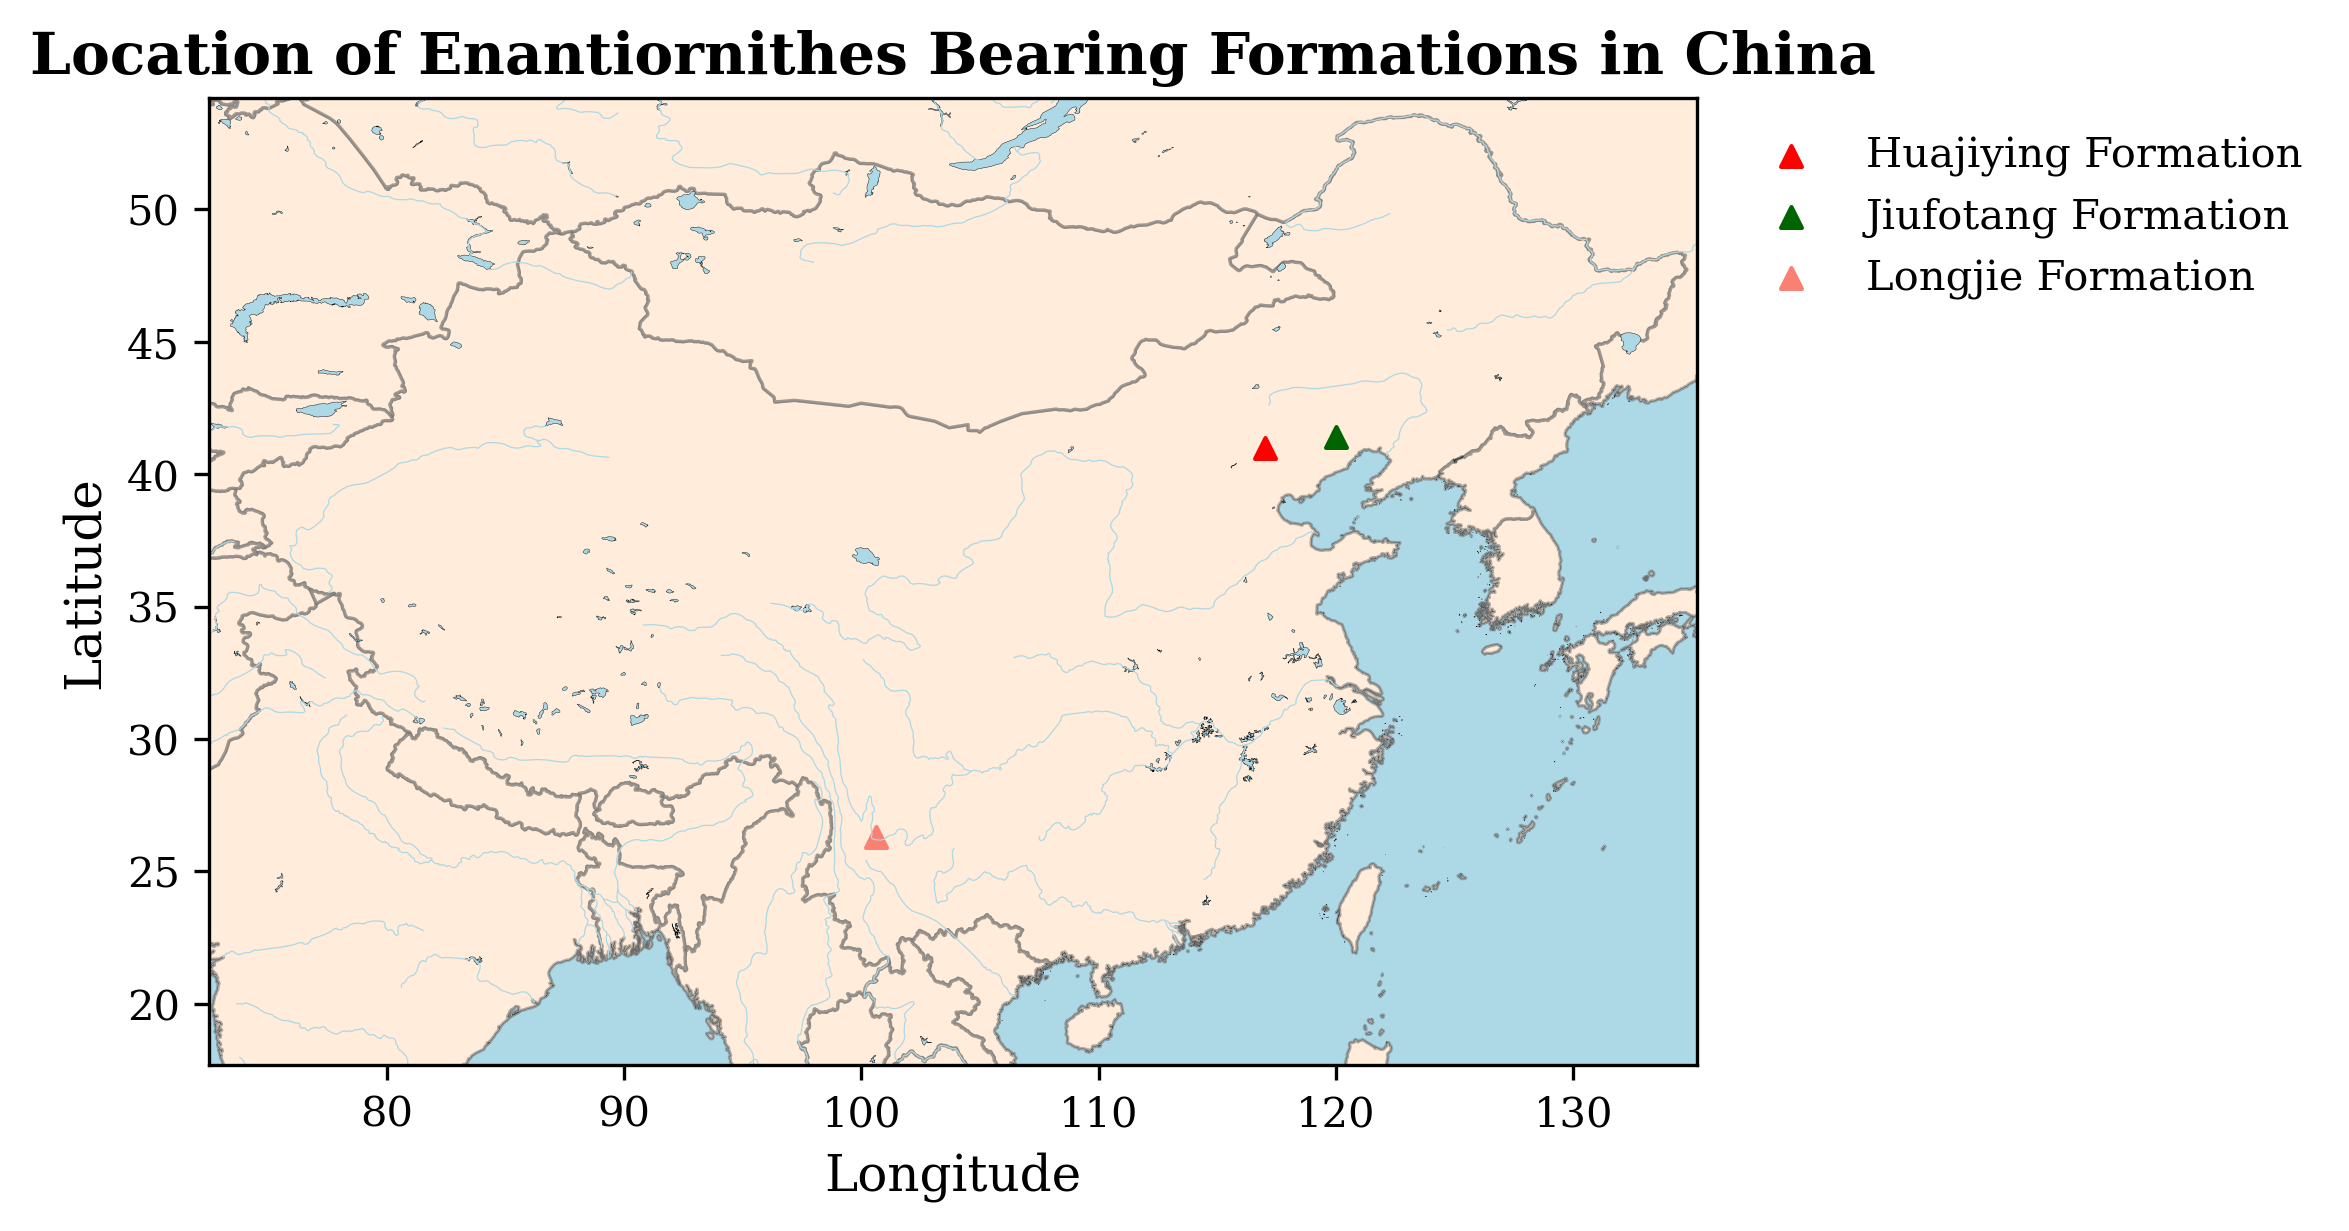

In [3]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(17.68,54.2)
ax.set_xlim(72.52,135.20)

oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0.1
)

countries.plot(
    ax=ax, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.8, alpha=0.5
)

lakes.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0.1
)

rivers.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0.3
)

def fmplots():
    huajiyingfm.plot(
        ax=ax, color="red", markersize=25, marker="^", label="Huajiying Formation"
    )

    jiufotangfm.plot(
        ax=ax, color="darkgreen", markersize=25, marker="^", label="Jiufotang Formation"
    )

    longjiefm.plot(
        ax=ax, color="salmon", markersize=25, marker="^", label="Longjie Formation"
    )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

fmplots()
plt.grid(False)
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Location of Enantiornithes Bearing Formations in China", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_china_formations.png', bbox_inches='tight', dpi=300)
plt.show()

/var/folders/cn/w96jhnkd6qsfv0xyljd8l2540000gn/T/ipykernel_5130/1513909304.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


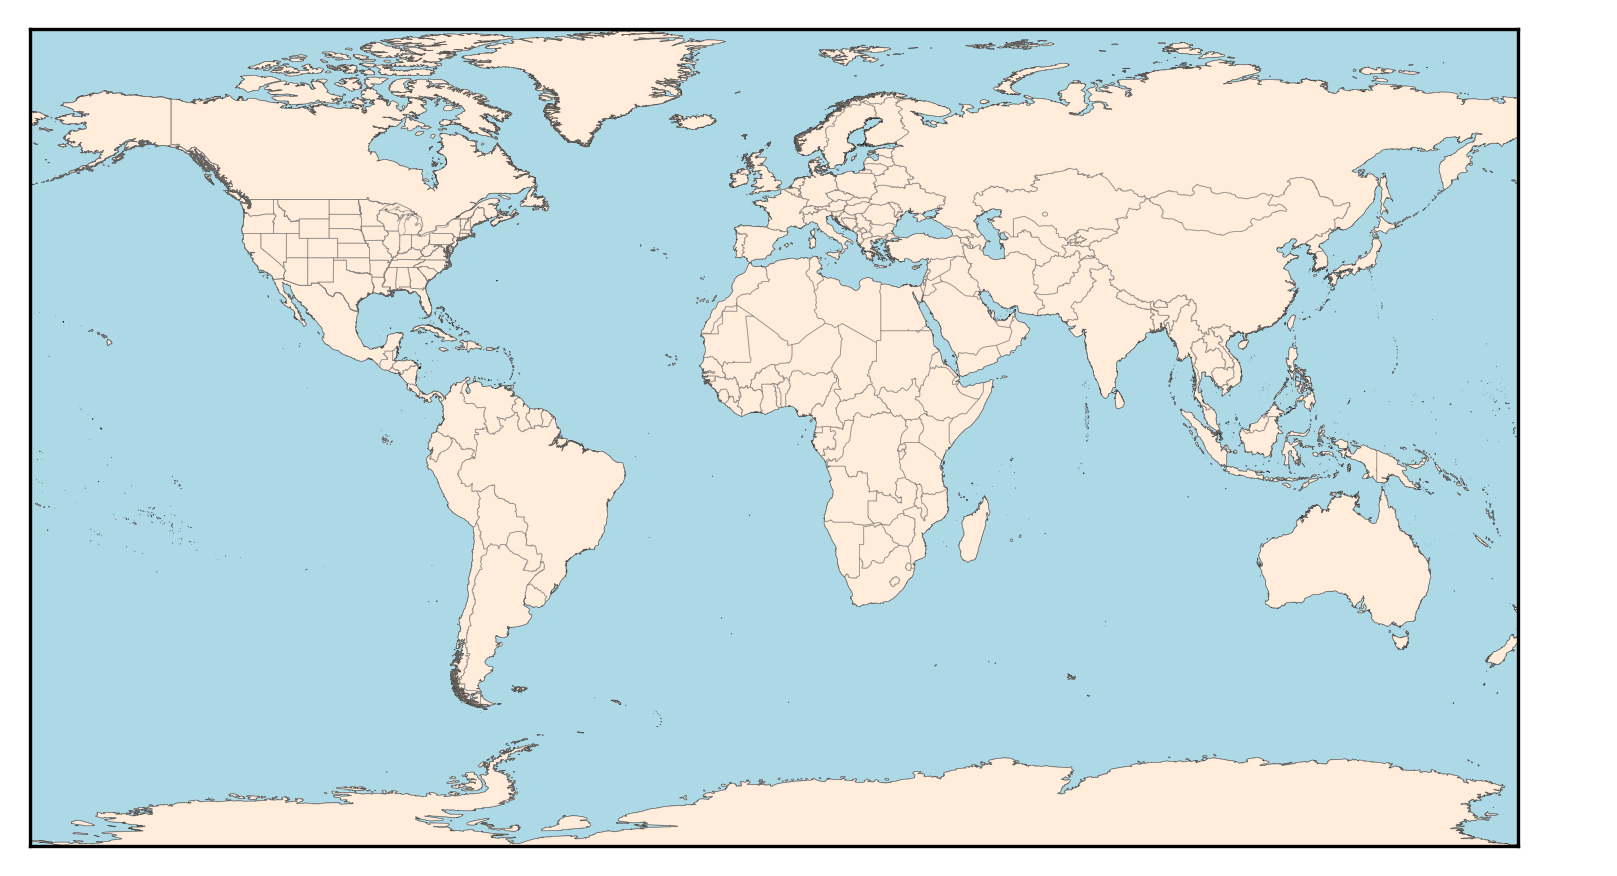

In [4]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(-84,84)
ax.set_xlim(-174,174)
#defining

solnhofenfm = gpd.GeoDataFrame(
    {"geometry": [Point(11, 48.9)]}, crs=states.crs
)
smokeychalkmb = gpd.GeoDataFrame(
    {"geometry": [Point(-100.9425, 38.8025)]}, crs=states.crs
)
#plotting

oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0.1
)

countries.plot(
    ax=ax, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.2, alpha=0.5
)

state_borders.plot(
    ax=ax, edgecolor="dimgray", facecolor="none", linewidth=0.2, alpha=0.5
)



def fmplots():
    jiufotangfm.plot(
        ax=ax, color="darkgreen", markersize=25, marker="^", label="Jiufotang Formation"
    )
    solnhofenfm.plot(
        ax=ax, color="red", markersize=25, marker="^", label="Solnhofen Formation"
    )
    smokeychalkmb.plot(
        ax=ax, color="blue", markersize=25, marker="^", label="Niobrara Formation"
    )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

# fmplots()
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)
ax.set_xticks([])
ax.set_yticks([])
# plt.xlabel("Longitude", fontsize=12)
# plt.ylabel("Latitude", fontsize=12)
#plt.title("Locations of Major Early-Bird Bearing Formations", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map of world.png', bbox_inches='tight', dpi=300)
plt.show()

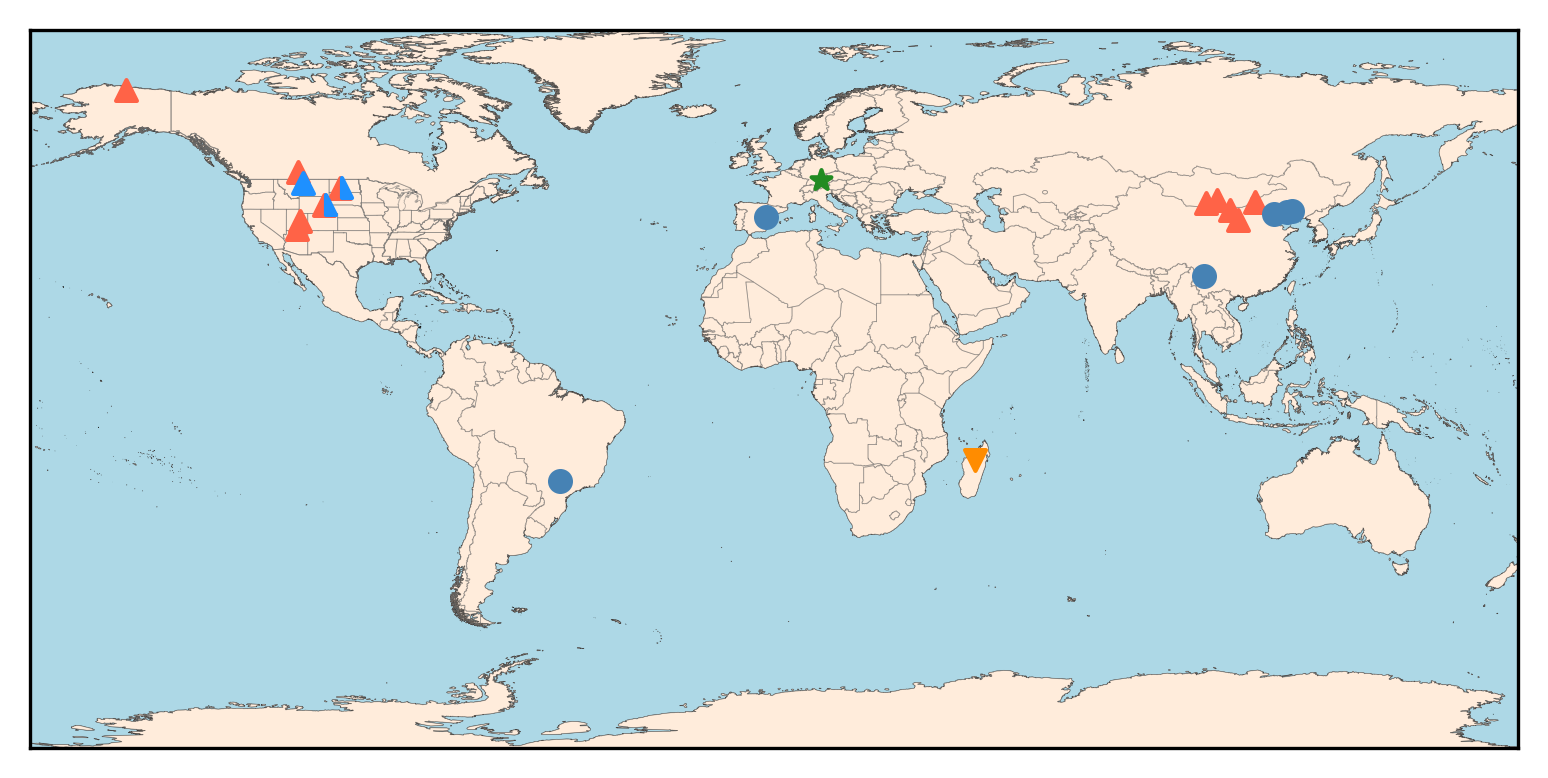

In [16]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(-84,84)
ax.set_xlim(-174,174)

plt.rcParams['text.usetex'] = False

#defining
#Dino Park, Hell Creek, Kaiparowits
trdata = {
    'Formation': ['Dino Park','Hell Creek', 'Kaiparowits','Djadochta','Nemegt','Bayan Mandahu','Iren','Ejinhoro','Ceder Mt','Lance','Prince Creek'],
    'State/Province': ['Alberta','Montana', 'Utah','Mongolia','Mongolia','China','China','China','Utah','Wyoming','Alaska'],
    'Latitude': [50.76, 46.9, 37.4,44.13,43.5,41.75,43.8,39.4,39.25,43,70],
    'Longitude': [-111.4, -101.5, -111.63,103.72,101,106.75,112.4,108.4,-110.8,-105.3,-151.5]
}
trf = pd.DataFrame(trdata)
trg = gpd.GeoDataFrame(trf,geometry=gpd.points_from_xy(trf.Longitude, trf.Latitude),crs=states.crs)

endata = {
    'Formation': ['huajiying','jiufotang', 'longjie','Adamantina','Huergina','Yixian'],
    'State/Province': ['China','China', 'China','Brazil','Spain','China'],
    'Latitude': [41, 41.4, 26.3,-21.6,40.0897,41.533],
    'Longitude': [117, 120, 100.6,-50.1,-1.8978,121.23]
}
enf = pd.DataFrame(endata)
eng = gpd.GeoDataFrame(enf,geometry=gpd.points_from_xy(enf.Longitude, enf.Latitude),crs=states.crs)

ordata = {
    'Formation': ['Hell Creek','Lance'],
    'State/Province': ['Montana','Wyoming'],
    'Latitude': [46.9,43],
    'Longitude': [-101,-104.8]
}
orf = pd.DataFrame(ordata)
org = gpd.GeoDataFrame(orf, geometry=gpd.points_from_xy(orf.Longitude, orf.Latitude),crs=states.crs)

judithriverfm = gpd.GeoDataFrame(
    {"geometry": [Point(-110.22,48.18)]}, crs=states.crs
)

rahonavis = gpd.GeoDataFrame(
    {"geometry": [Point(47.03,-16.76)]}
)

#plotting
oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0.1
)

countries.plot(
    ax=ax, edgecolor="dimgray", facecolor="peachpuff", linewidth=0.2, alpha=0.5
)

state_borders.plot(
    ax=ax, edgecolor="dimgray", facecolor="none", linewidth=0.2, alpha=0.5
)

def listplots():
    trg.plot(
        ax=ax, color="tomato", markersize=25, marker="^", label="Troodontid Formations"
    )

    eng.plot(
        ax=ax, color="steelblue", markersize=25, marker="o", label="Enantiornithes Formations"
    )

    org.plot(
        ax=ax, color="dodgerblue", markersize=25, marker=MarkerStyle('^', fillstyle='right')

    )

def otherplots():
    judithriverfm.plot(
        ax=ax, color="dodgerblue", markersize=25, marker="^", label="Hesperornithes Formations"
    )

    solnhofenfm.plot(
        ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
    )

    rahonavis.plot(
        ax=ax, color="darkorange", markersize=25, marker="v", label="${Rahonavis}$"
    )

listplots()
otherplots()

ax.set_xticks([])
ax.set_yticks([])
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, labels)
plt.grid(False)
# plt.legend(
#     loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
# )
# plt.xlabel("Longitude", fontsize=12)
# plt.ylabel("Latitude", fontsize=12)
#plt.title("Locations of Major Paraves Bearing Formations", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_paraves_formations.png', bbox_inches='tight', dpi=300)
plt.show()

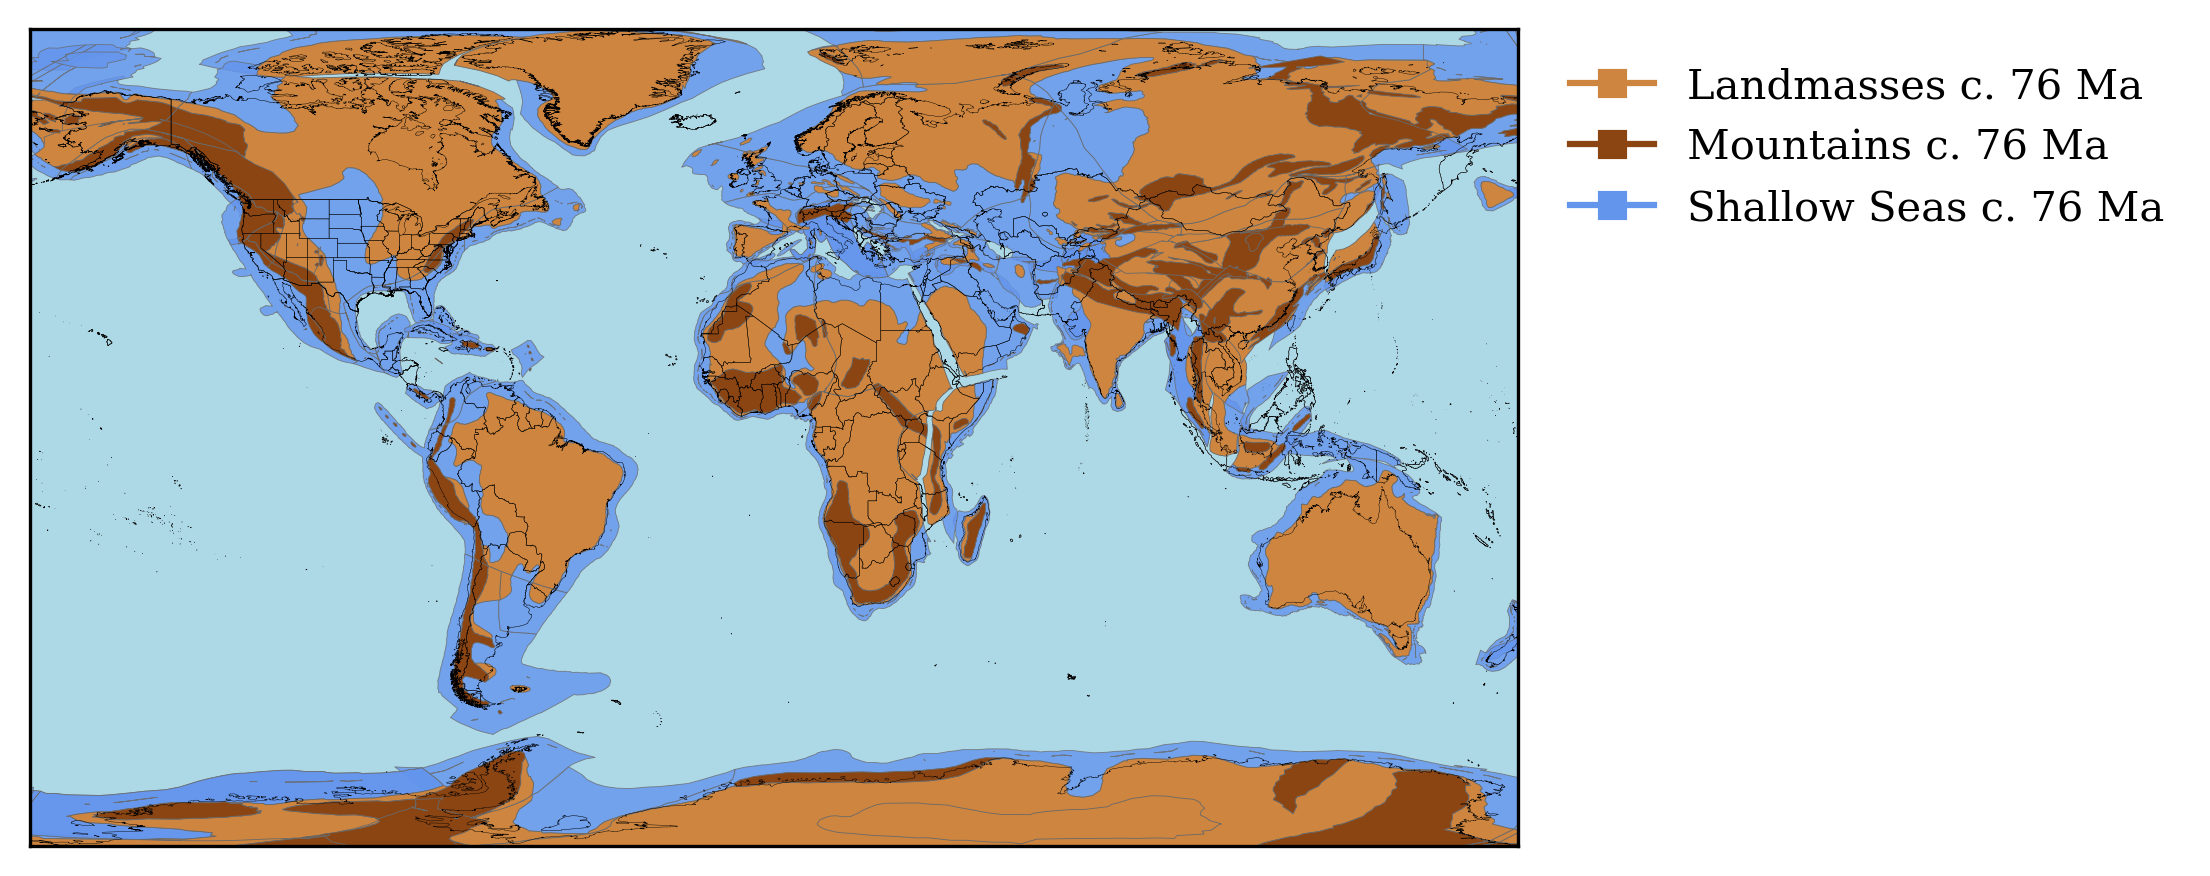

In [14]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(-84,84)
ax.set_xlim(-174,174)

plt.rcParams['text.usetex'] = False

#defining
#Dino Park, Hell Creek, Kaiparowits
trdata = {
    'Formation': ['Dino Park','Hell Creek', 'Kaiparowits','Djadochta','Nemegt','Bayan Mandahu','Iren','Ejinhoro','Ceder Mt','Lance','Prince Creek'],
    'State/Province': ['Alberta','Montana', 'Utah','Mongolia','Mongolia','China','China','China','Utah','Wyoming','Alaska'],
    'Latitude': [50.76, 46.9, 37.4,44.13,43.5,41.75,43.8,39.4,39.25,43,70],
    'Longitude': [-111.4, -101.5, -111.63,103.72,101,106.75,112.4,108.4,-110.8,-105.3,-151.5]
}
trf = pd.DataFrame(trdata)
trg = gpd.GeoDataFrame(trf,geometry=gpd.points_from_xy(trf.Longitude, trf.Latitude),crs=states.crs)

endata = {
    'Formation': ['huajiying','jiufotang', 'longjie','Adamantina','Huergina','Yixian'],
    'State/Province': ['China','China', 'China','Brazil','Spain','China'],
    'Latitude': [41, 41.4, 26.3,-21.6,40.0897,41.533],
    'Longitude': [117, 120, 100.6,-50.1,-1.8978,121.23]
}
enf = pd.DataFrame(endata)
eng = gpd.GeoDataFrame(enf,geometry=gpd.points_from_xy(enf.Longitude, enf.Latitude),crs=states.crs)

ordata = {
    'Formation': ['Hell Creek','Lance'],
    'State/Province': ['Montana','Wyoming'],
    'Latitude': [46.9,43],
    'Longitude': [-101,-104.8]
}
orf = pd.DataFrame(ordata)
org = gpd.GeoDataFrame(orf, geometry=gpd.points_from_xy(orf.Longitude, orf.Latitude),crs=states.crs)

judithriverfm = gpd.GeoDataFrame(
    {"geometry": [Point(-110.22,48.18)]}, crs=states.crs
)

rahonavis = gpd.GeoDataFrame(
    {"geometry": [Point(47.03,-16.76)]}
)

#plotting

def cretaceousplot():
    cretaceoussm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="cornflowerblue", linewidth=0.2, alpha=0.8
    )
    cretaceouslm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="peru", linewidth=0.2, alpha=1
    )
    cretaceousmts.plot(
        ax=ax, edgecolor="dimgrey", facecolor="saddlebrown", linewidth=0.2, alpha=1
    )


oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0
)

def listplots():
    trg.plot(
        ax=ax, color="black", markersize=25, marker="^", label="Troodontid Formations"
    )

    eng.plot(
        ax=ax, edgecolor="dimgrey", facecolor="white", markersize=25, marker="o", label="Enantiornithes Formations"
    )

    org.plot(
        ax=ax, color="white", markersize=25, marker=MarkerStyle('^', fillstyle='right')

    )


def otherplots():
    judithriverfm.plot(
        ax=ax, color="white", markersize=25, marker="^", label="Hesperornithes Formations"
    )

    # solnhofenfm.plot(
    #     ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
    # )

    rahonavis.plot(
        ax=ax, color="black", markersize=25, marker="v", label="${Rahonavis}$"
    )



countries.plot(
    ax=ax, edgecolor="black", facecolor="lightblue", linewidth=0.1
)
cretaceousplot()
countries.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
state_borders.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
# listplots()
# otherplots()

plt.plot(np.nan, np.nan, color='peru', marker="s", label='Landmasses c. 76 Ma')
plt.plot(np.nan, np.nan, color='saddlebrown', marker="s", label='Mountains c. 76 Ma')
plt.plot(np.nan, np.nan, color='cornflowerblue', marker="s", label='Shallow Seas c. 76 Ma')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.grid(False)
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)

ax.set_xticks([])
ax.set_yticks([])
# plt.xlabel("Longitude", fontsize=12)
# plt.ylabel("Latitude", fontsize=12)

#plt.title("Locations of Landmasses in the Cretaceous", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_cretaceous.png', bbox_inches='tight', dpi=300)
plt.show()

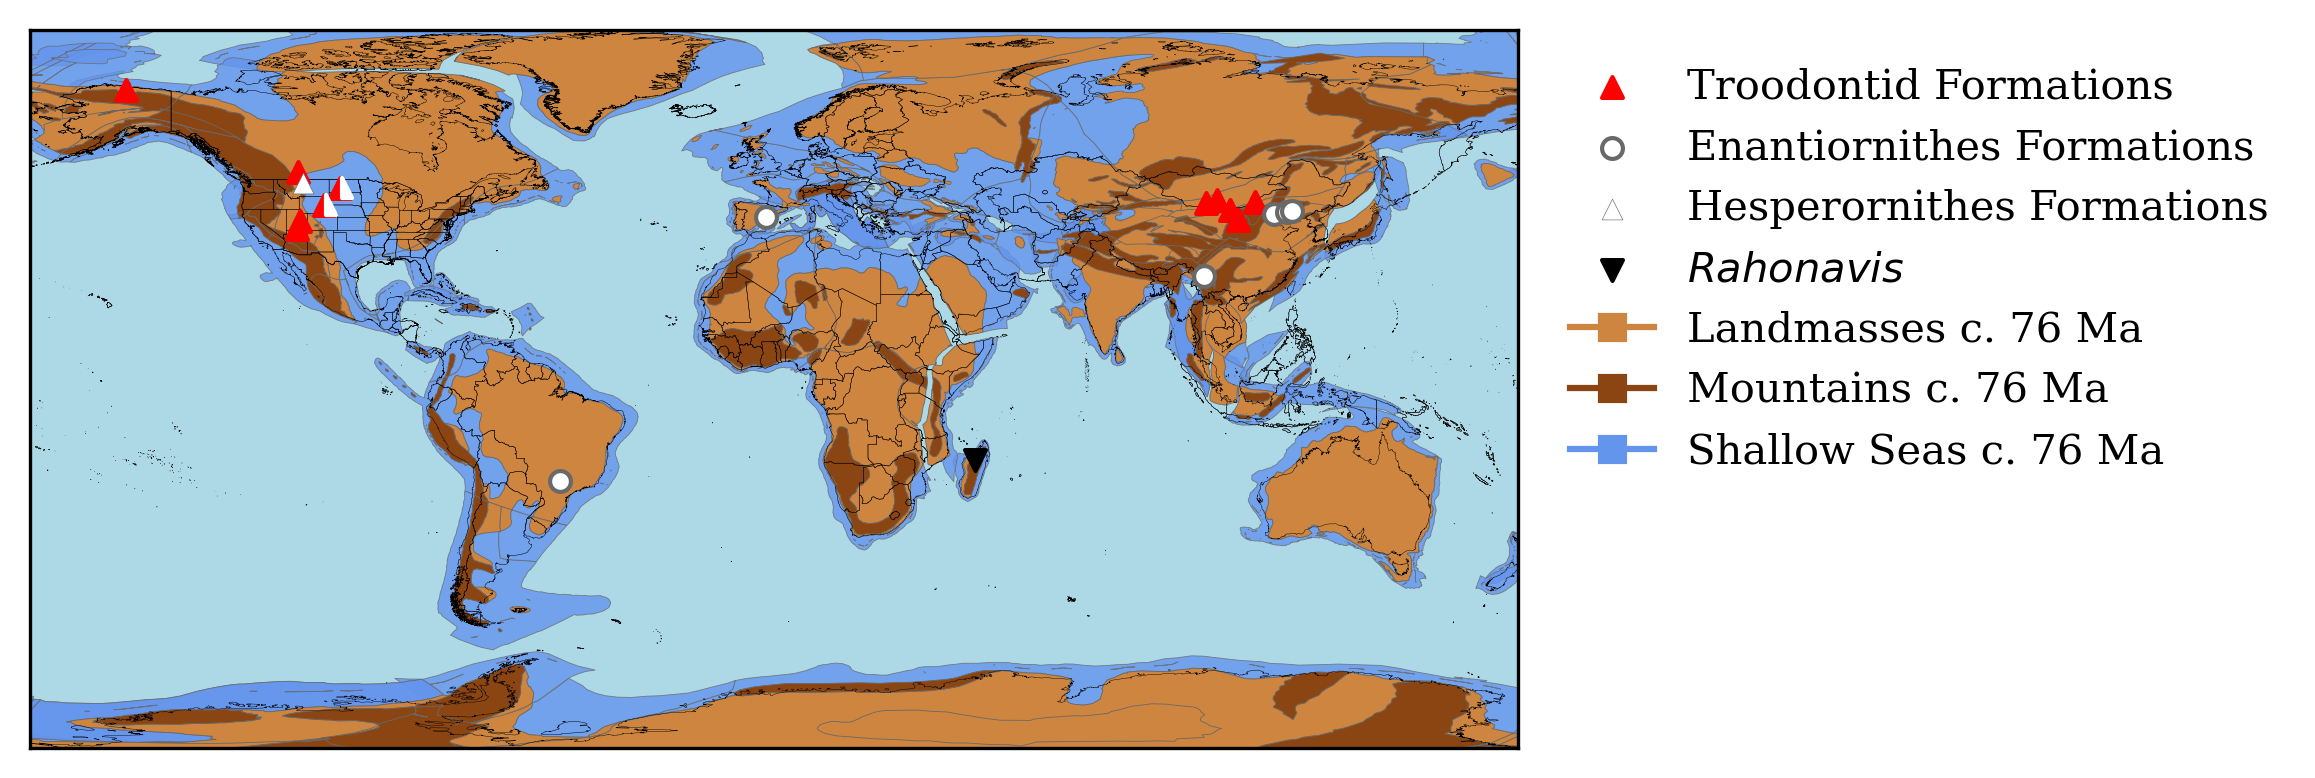

In [6]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(-84,84)
ax.set_xlim(-174,174)

plt.rcParams['text.usetex'] = False

#defining
#Dino Park, Hell Creek, Kaiparowits
trdata = {
    'Formation': ['Dino Park','Hell Creek', 'Kaiparowits','Djadochta','Nemegt','Bayan Mandahu','Iren','Ejinhoro','Ceder Mt','Lance','Prince Creek'],
    'State/Province': ['Alberta','Montana', 'Utah','Mongolia','Mongolia','China','China','China','Utah','Wyoming','Alaska'],
    'Latitude': [50.76, 46.9, 37.4,44.13,43.5,41.75,43.8,39.4,39.25,43,70],
    'Longitude': [-111.4, -101.5, -111.63,103.72,101,106.75,112.4,108.4,-110.8,-105.3,-151.5]
}
trf = pd.DataFrame(trdata)
trg = gpd.GeoDataFrame(trf,geometry=gpd.points_from_xy(trf.Longitude, trf.Latitude),crs=states.crs)

endata = {
    'Formation': ['huajiying','jiufotang', 'longjie','Adamantina','Huergina','Yixian'],
    'State/Province': ['China','China', 'China','Brazil','Spain','China'],
    'Latitude': [41, 41.4, 26.3,-21.6,40.0897,41.533],
    'Longitude': [117, 120, 100.6,-50.1,-1.8978,121.23]
}
enf = pd.DataFrame(endata)
eng = gpd.GeoDataFrame(enf,geometry=gpd.points_from_xy(enf.Longitude, enf.Latitude),crs=states.crs)

ordata = {
    'Formation': ['Hell Creek','Lance'],
    'State/Province': ['Montana','Wyoming'],
    'Latitude': [46.9,43],
    'Longitude': [-101,-104.8]
}
orf = pd.DataFrame(ordata)
org = gpd.GeoDataFrame(orf, geometry=gpd.points_from_xy(orf.Longitude, orf.Latitude),crs=states.crs)

judithriverfm = gpd.GeoDataFrame(
    {"geometry": [Point(-110.22,48.18)]}, crs=states.crs
)

rahonavis = gpd.GeoDataFrame(
    {"geometry": [Point(47.03,-16.76)]}
)

#plotting

def cretaceousplot():
    cretaceoussm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="cornflowerblue", linewidth=0.2, alpha=0.8
    )
    cretaceouslm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="peru", linewidth=0.2, alpha=1
    )
    cretaceousmts.plot(
        ax=ax, edgecolor="dimgrey", facecolor="saddlebrown", linewidth=0.2, alpha=1
    )


oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0
)

# state_borders.plot(
#     ax=ax, edgecolor="dimgray", facecolor="lightblue", linewidth=0.2, alpha=0.5
# )

def listplots():
    trg.plot(
        ax=ax, color="red", markersize=25, marker="^", label="Troodontid Formations"
    )

    eng.plot(
        ax=ax, edgecolor="dimgrey", facecolor="white", markersize=25, marker="o", label="Enantiornithes Formations"
    )

    org.plot(
        ax=ax, color="white", markersize=25, marker=MarkerStyle('^', fillstyle='right')

    )


def otherplots():
    judithriverfm.plot(
        ax=ax, edgecolor="dimgrey", linewidth=0.15, facecolor="white", markersize=25, marker="^", label="Hesperornithes Formations"
    )

    # solnhofenfm.plot(
    #     ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
    # )

    rahonavis.plot(
        ax=ax, color="black", markersize=25, marker="v", label="${Rahonavis}$"
    )

countries.plot(
    ax=ax, edgecolor="black", facecolor="lightblue", linewidth=0.1
)
cretaceousplot()
countries.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
state_borders.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
listplots()
otherplots()

plt.plot(np.nan, np.nan, color='peru', marker="s", label='Landmasses c. 76 Ma')
plt.plot(np.nan, np.nan, color='saddlebrown', marker="s", label='Mountains c. 76 Ma')
plt.plot(np.nan, np.nan, color='cornflowerblue', marker="s", label='Shallow Seas c. 76 Ma')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.grid(False)
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)

ax.set_xticks([])
ax.set_yticks([])
# plt.xlabel("Longitude", fontsize=12)
# plt.ylabel("Latitude", fontsize=12)

#plt.title("Locations of Major Paraves Bearing Formations", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_paraves_formations_with_cretaceous.png', bbox_inches='tight', dpi=300)
plt.show()

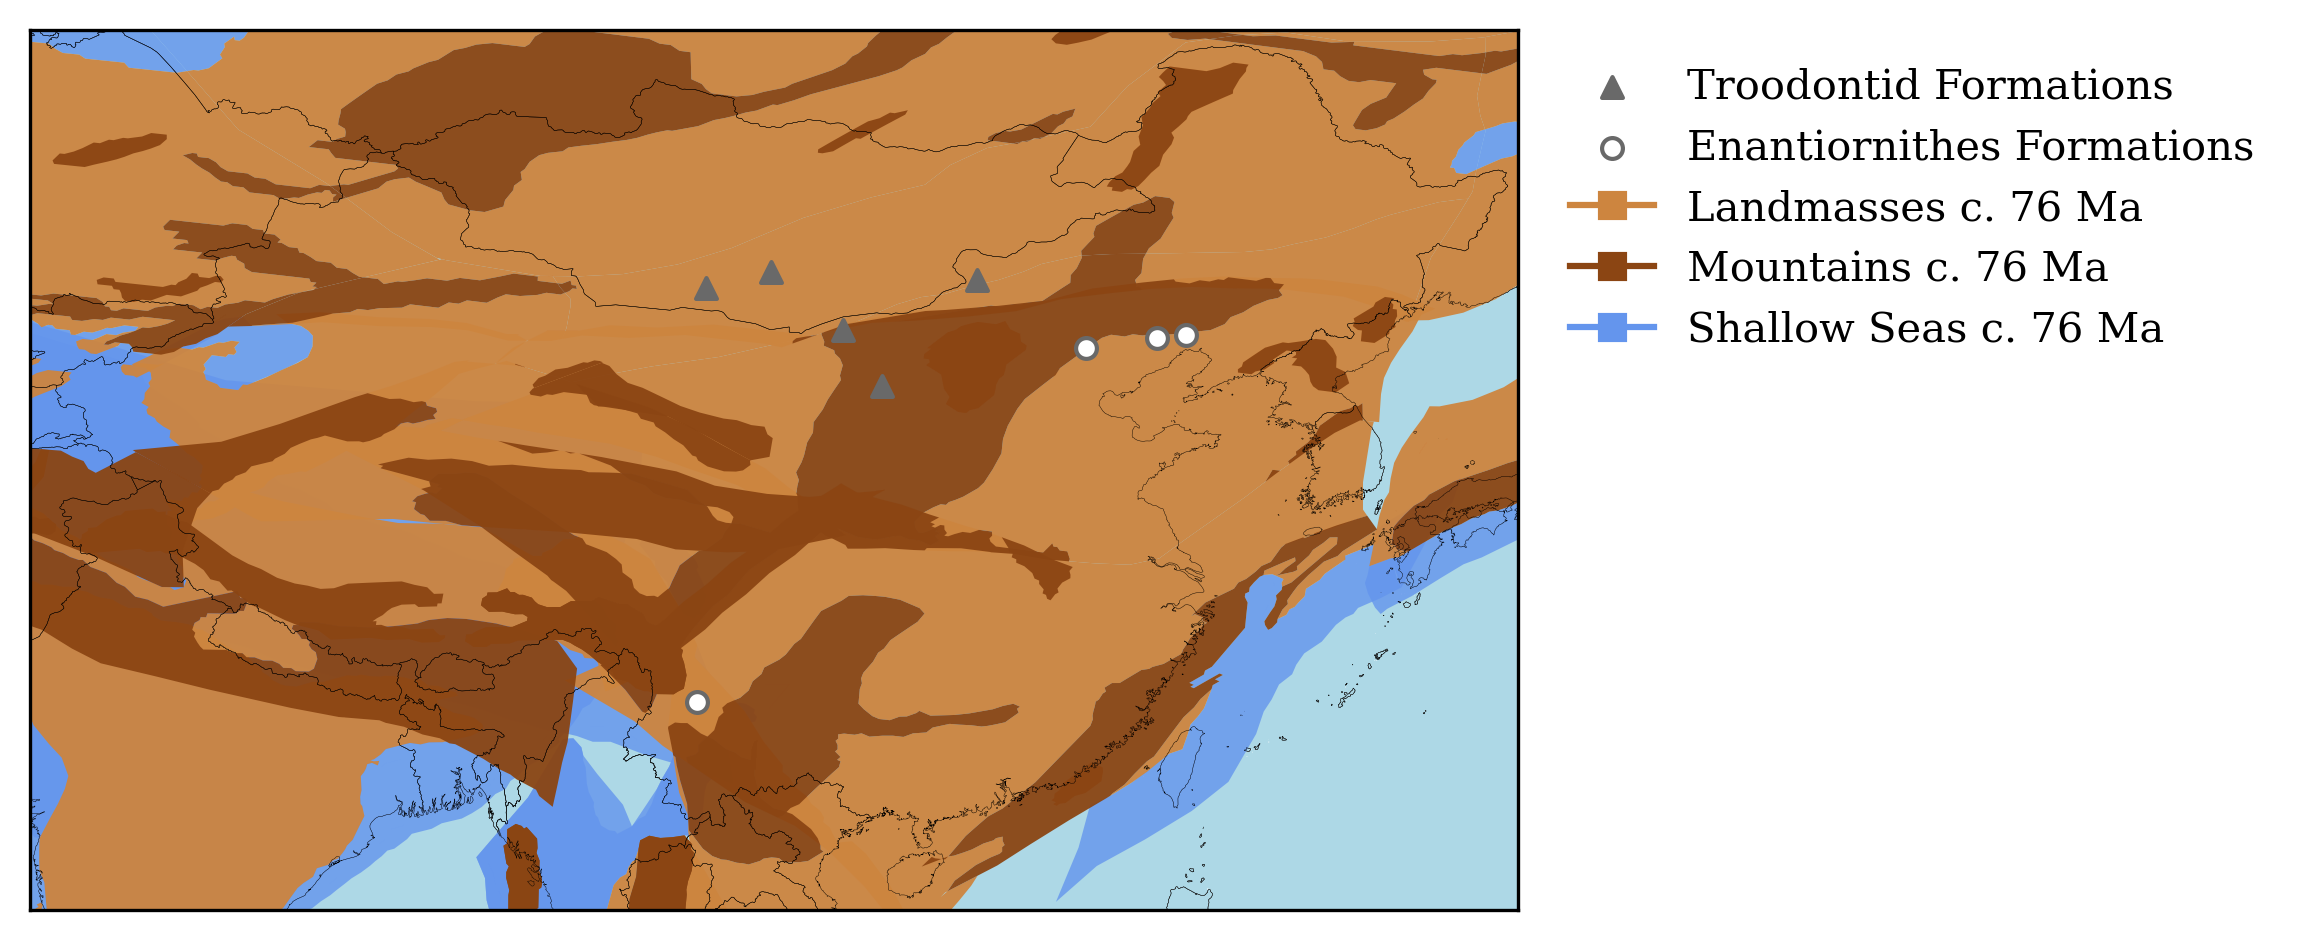

In [80]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(17.68,54.2)
ax.set_xlim(72.52,135.20)

plt.rcParams['text.usetex'] = False

#defining
#Dino Park, Hell Creek, Kaiparowits
trdata = {
    'Formation': ['Dino Park','Hell Creek', 'Kaiparowits','Djadochta','Nemegt','Bayan Mandahu','Iren','Ejinhoro','Ceder Mt','Lance','Prince Creek'],
    'State/Province': ['Alberta','Montana', 'Utah','Mongolia','Mongolia','China','China','China','Utah','Wyoming','Alaska'],
    'Latitude': [50.76, 46.9, 37.4,44.13,43.5,41.75,43.8,39.4,39.25,43,70],
    'Longitude': [-111.4, -101.5, -111.63,103.72,101,106.75,112.4,108.4,-110.8,-105.3,-151.5]
}
trf = pd.DataFrame(trdata)
trg = gpd.GeoDataFrame(trf,geometry=gpd.points_from_xy(trf.Longitude, trf.Latitude),crs=states.crs)

endata = {
    'Formation': ['huajiying','jiufotang', 'longjie','Adamantina','Huergina','Yixian'],
    'State/Province': ['China','China', 'China','Brazil','Spain','China'],
    'Latitude': [41, 41.4, 26.3,-21.6,40.0897,41.533],
    'Longitude': [117, 120, 100.6,-50.1,-1.8978,121.23]
}
enf = pd.DataFrame(endata)
eng = gpd.GeoDataFrame(enf,geometry=gpd.points_from_xy(enf.Longitude, enf.Latitude),crs=states.crs)

ordata = {
    'Formation': ['Hell Creek','Lance'],
    'State/Province': ['Montana','Wyoming'],
    'Latitude': [46.9,43],
    'Longitude': [-101,-104.8]
}
orf = pd.DataFrame(ordata)
org = gpd.GeoDataFrame(orf, geometry=gpd.points_from_xy(orf.Longitude, orf.Latitude),crs=states.crs)

judithriverfm = gpd.GeoDataFrame(
    {"geometry": [Point(-110.22,48.18)]}, crs=states.crs
)

rahonavis = gpd.GeoDataFrame(
    {"geometry": [Point(47.03,-16.76)]}
)

#plotting

def cretaceousplot():
    cretaceoussm.plot(
        ax=ax, edgecolor="none", facecolor="cornflowerblue", linewidth=0.2, alpha=0.8
    )
    cretaceouslm.plot(
        ax=ax, edgecolor="none", facecolor="peru", linewidth=0.2, alpha=0.95
    )
    cretaceousmts.plot(
        ax=ax, edgecolor="none", facecolor="saddlebrown", linewidth=0.2, alpha=0.95
    )



oceans.plot(
    ax=ax, color="lightblue", edgecolor="black", linewidth=0
)



# state_borders.plot(
#     ax=ax, edgecolor="dimgray", facecolor="lightblue", linewidth=0.2, alpha=0.5
# )

def listplots1():
    trg.plot(
        ax=ax, color="dimgrey", markersize=25, marker="^", label="Troodontid Formations"
    )

    eng.plot(
        ax=ax, edgecolor="dimgrey", facecolor="white", markersize=25, marker="o", label="Enantiornithes Formations"
    )

    # org.plot(
    #     ax=ax, color="white", markersize=25, marker=MarkerStyle('^', fillstyle='right')

    # )


# def otherplots():
#     # judithriverfm.plot(
#     #     ax=ax, edgecolor="dimgrey", linewidth=0.15, facecolor="white", markersize=25, marker="^", label="Hesperornithes Formations"
#     # )

#     # solnhofenfm.plot(
#     #     ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
#     # )

#     # rahonavis.plot(
#     #     ax=ax, color="black", markersize=25, marker="v", label="${Rahonavis}$"
#     # )



countries.plot(
    ax=ax, edgecolor="black", facecolor="lightblue", linewidth=0.1
)
cretaceousplot()
countries.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
state_borders.plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.1
)
listplots1()
# otherplots()

plt.plot(np.nan, np.nan, color='peru', marker="s", label='Landmasses c. 76 Ma')
plt.plot(np.nan, np.nan, color='saddlebrown', marker="s", label='Mountains c. 76 Ma')
plt.plot(np.nan, np.nan, color='cornflowerblue', marker="s", label='Shallow Seas c. 76 Ma')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.grid(False)
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)

ax.set_xticks([])
ax.set_yticks([])
# plt.xlabel("Longitude", fontsize=12)
# plt.ylabel("Latitude", fontsize=12)

#plt.title("Locations of Major Paraves Bearing Formations", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_china_with_cretaceous.png', bbox_inches='tight', dpi=300)
plt.show()

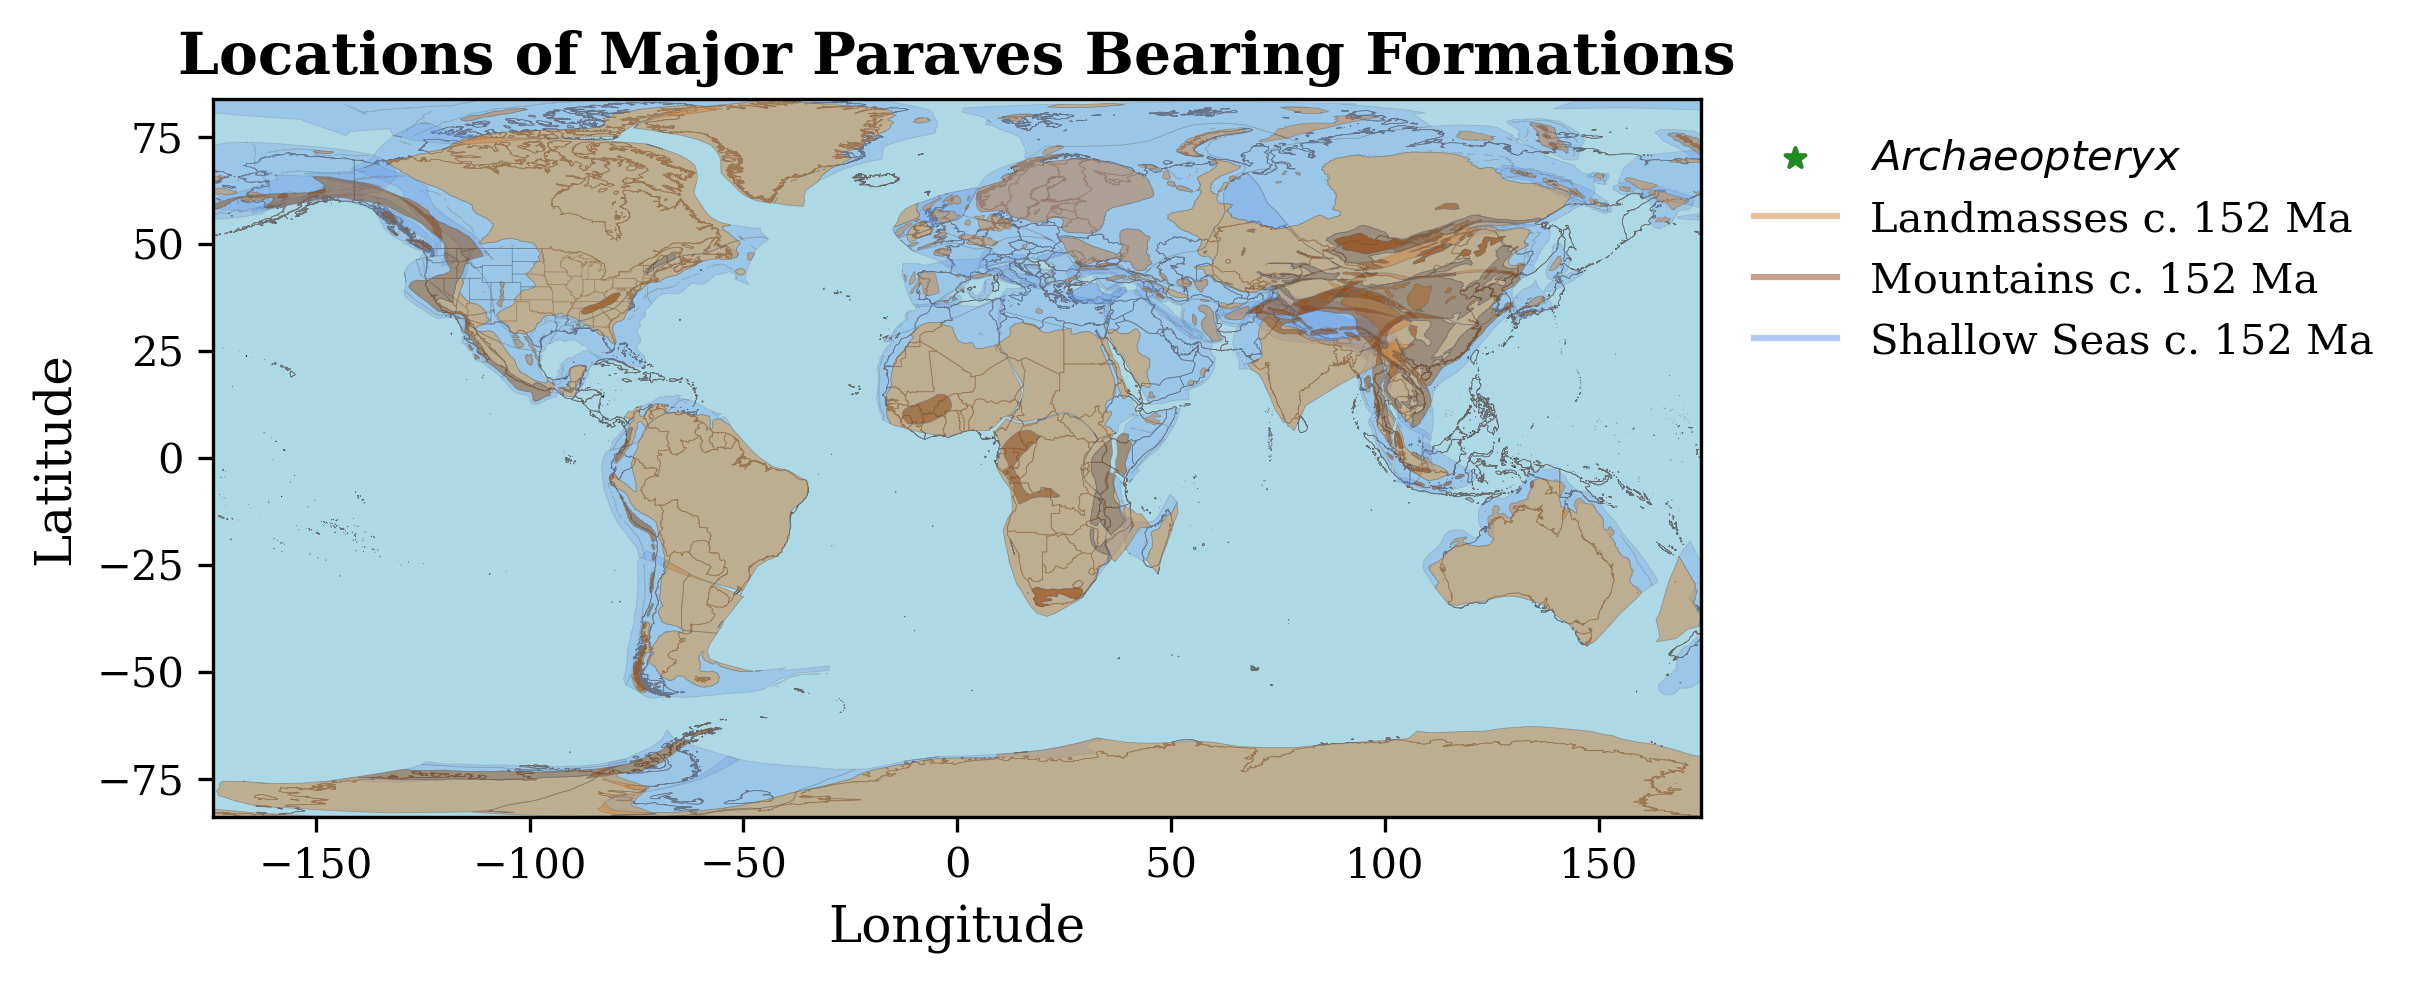

In [20]:
fig = plt.figure(
    dpi=300
)

ax = fig.add_subplot(
    111
)

ax.set_ylim(-84,84)
ax.set_xlim(-174,174)

plt.rcParams['text.usetex'] = False

#defining
#Dino Park, Hell Creek, Kaiparowits
trdata = {
    'Formation': ['Dino Park','Hell Creek', 'Kaiparowits','Djadochta','Nemegt','Bayan Mandahu','Iren','Ejinhoro','Ceder Mt','Lance','Prince Creek'],
    'State/Province': ['Alberta','Montana', 'Utah','Mongolia','Mongolia','China','China','China','Utah','Wyoming','Alaska'],
    'Latitude': [50.76, 46.9, 37.4,44.13,43.5,41.75,43.8,39.4,39.25,43,70],
    'Longitude': [-111.4, -101.5, -111.63,103.72,101,106.75,112.4,108.4,-110.8,-105.3,-151.5]
}
trf = pd.DataFrame(trdata)
trg = gpd.GeoDataFrame(trf,geometry=gpd.points_from_xy(trf.Longitude, trf.Latitude),crs=states.crs)

endata = {
    'Formation': ['huajiying','jiufotang', 'longjie','Adamantina','Huergina','Yixian'],
    'State/Province': ['China','China', 'China','Brazil','Spain','China'],
    'Latitude': [41, 41.4, 26.3,-21.6,40.0897,41.533],
    'Longitude': [117, 120, 100.6,-50.1,-1.8978,121.23]
}
enf = pd.DataFrame(endata)
eng = gpd.GeoDataFrame(enf,geometry=gpd.points_from_xy(enf.Longitude, enf.Latitude),crs=states.crs)

ordata = {
    'Formation': ['Hell Creek','Lance'],
    'State/Province': ['Montana','Wyoming'],
    'Latitude': [46.9,43],
    'Longitude': [-101,-104.8]
}
orf = pd.DataFrame(ordata)
org = gpd.GeoDataFrame(orf, geometry=gpd.points_from_xy(orf.Longitude, orf.Latitude),crs=states.crs)

judithriverfm = gpd.GeoDataFrame(
    {"geometry": [Point(-110.22,48.18)]}, crs=states.crs
)

rahonavis = gpd.GeoDataFrame(
    {"geometry": [Point(47.03,-16.76)]}
)

#plotting

def jurassicplots():
    jurassicsm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="cornflowerblue", linewidth=0.2, alpha=0.25
    )
    jurassiclm.plot(
        ax=ax, edgecolor="dimgrey", facecolor="peru", linewidth=0.2, alpha=0.5
    )
    jurassicmts.plot(
        ax=ax, edgecolor="dimgrey", facecolor="saddlebrown", linewidth=0.2, alpha=0.5
    )

def mapplots():
    oceans.plot(
        ax=ax, color="lightblue", edgecolor="black", linewidth=0.1
    )

    countries.plot(
        ax=ax, edgecolor="dimgray", facecolor="lightblue", linewidth=0.2
    )

    state_borders.plot(
        ax=ax, edgecolor="dimgray", facecolor="lightblue", linewidth=0.2, alpha=0.5
    )

# def listplots():
    # trg.plot(
    #     ax=ax, color="tomato", markersize=25, marker="^", label="Troodontid Formations"
    # )

    # eng.plot(
    #     ax=ax, color="steelblue", markersize=25, marker="o", label="Enantiornithes Formations"
    # )

    # org.plot(
    #     ax=ax, color="dodgerblue", markersize=25, marker=MarkerStyle('^', fillstyle='right')

    # )

# def otherplots():
#     # judithriverfm.plot(
#     #     ax=ax, color="dodgerblue", markersize=25, marker="^", label="Hesperornithes Formations"
#     # )

#     solnhofenfm.plot(
#         ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
#     )

    # rahonavis.plot(
    #     ax=ax, color="darkorange", markersize=25, marker="v", label="${Rahonavis}$"
    # )

solnhofenfm.plot(
    ax=ax, color="forestgreen", markersize=25, marker="*", label="${Archaeopteryx}$"
)

mapplots()
jurassicplots()
#listplots()
#otherplots()

plt.plot(np.nan, np.nan, color='peru', marker=None, alpha=0.5, label='Landmasses c. 152 Ma')
plt.plot(np.nan, np.nan, color='saddlebrown', marker=None, alpha=0.5, label='Mountains c. 152 Ma')
plt.plot(np.nan, np.nan, color='cornflowerblue', marker=None,alpha=0.5, label='Shallow Seas c. 152 Ma')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)
plt.grid(False)
plt.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.title("Locations of Major Paraves Bearing Formations", fontsize=14, fontdict={"weight": "bold"})
plt.savefig('Figures/Maps/map_of_paraves_formations_with_jurassic.png', bbox_inches='tight', dpi=300)
plt.show()

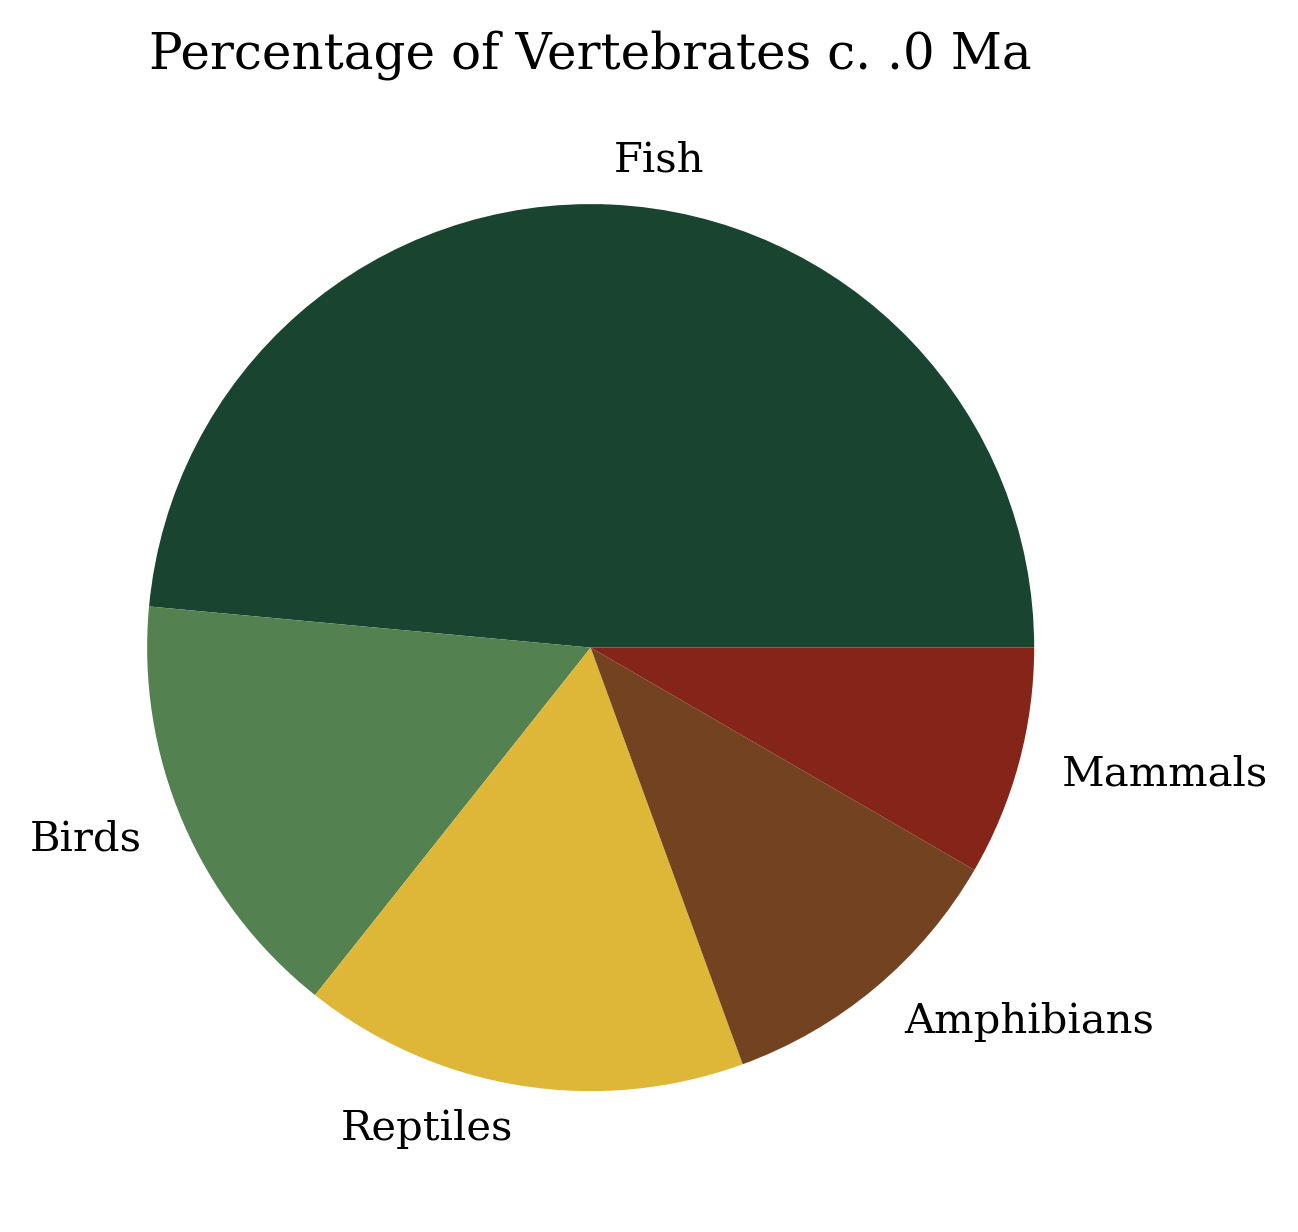

In [21]:
#labels = 'Birds (16.9%)', 'Reptiles (17%)', 'Fish (46%)', 'Mammals (9.3%)', 'Amphibians (11.3%)'

files = pd.read_csv('Data/Test - Sheet2.csv')
file_labels = files['name']

cmap = load_cmap("ClaudeMonet")
category_codes, unique_categories = pd.factorize(files["name"])
colors = [cmap(code) for code in category_codes]

# sizes = [16.9, 17, 46, 9.3, 11.3]

fig, ax = plt.subplots()
plt.title('Percentage of Vertebrates c. .0 Ma')

ax.pie(files['amount'], labels=file_labels, colors=colors)
plt.savefig('Figures/Piechart/vertebrate_pie_chart.png', bbox_inches='tight', dpi=300)

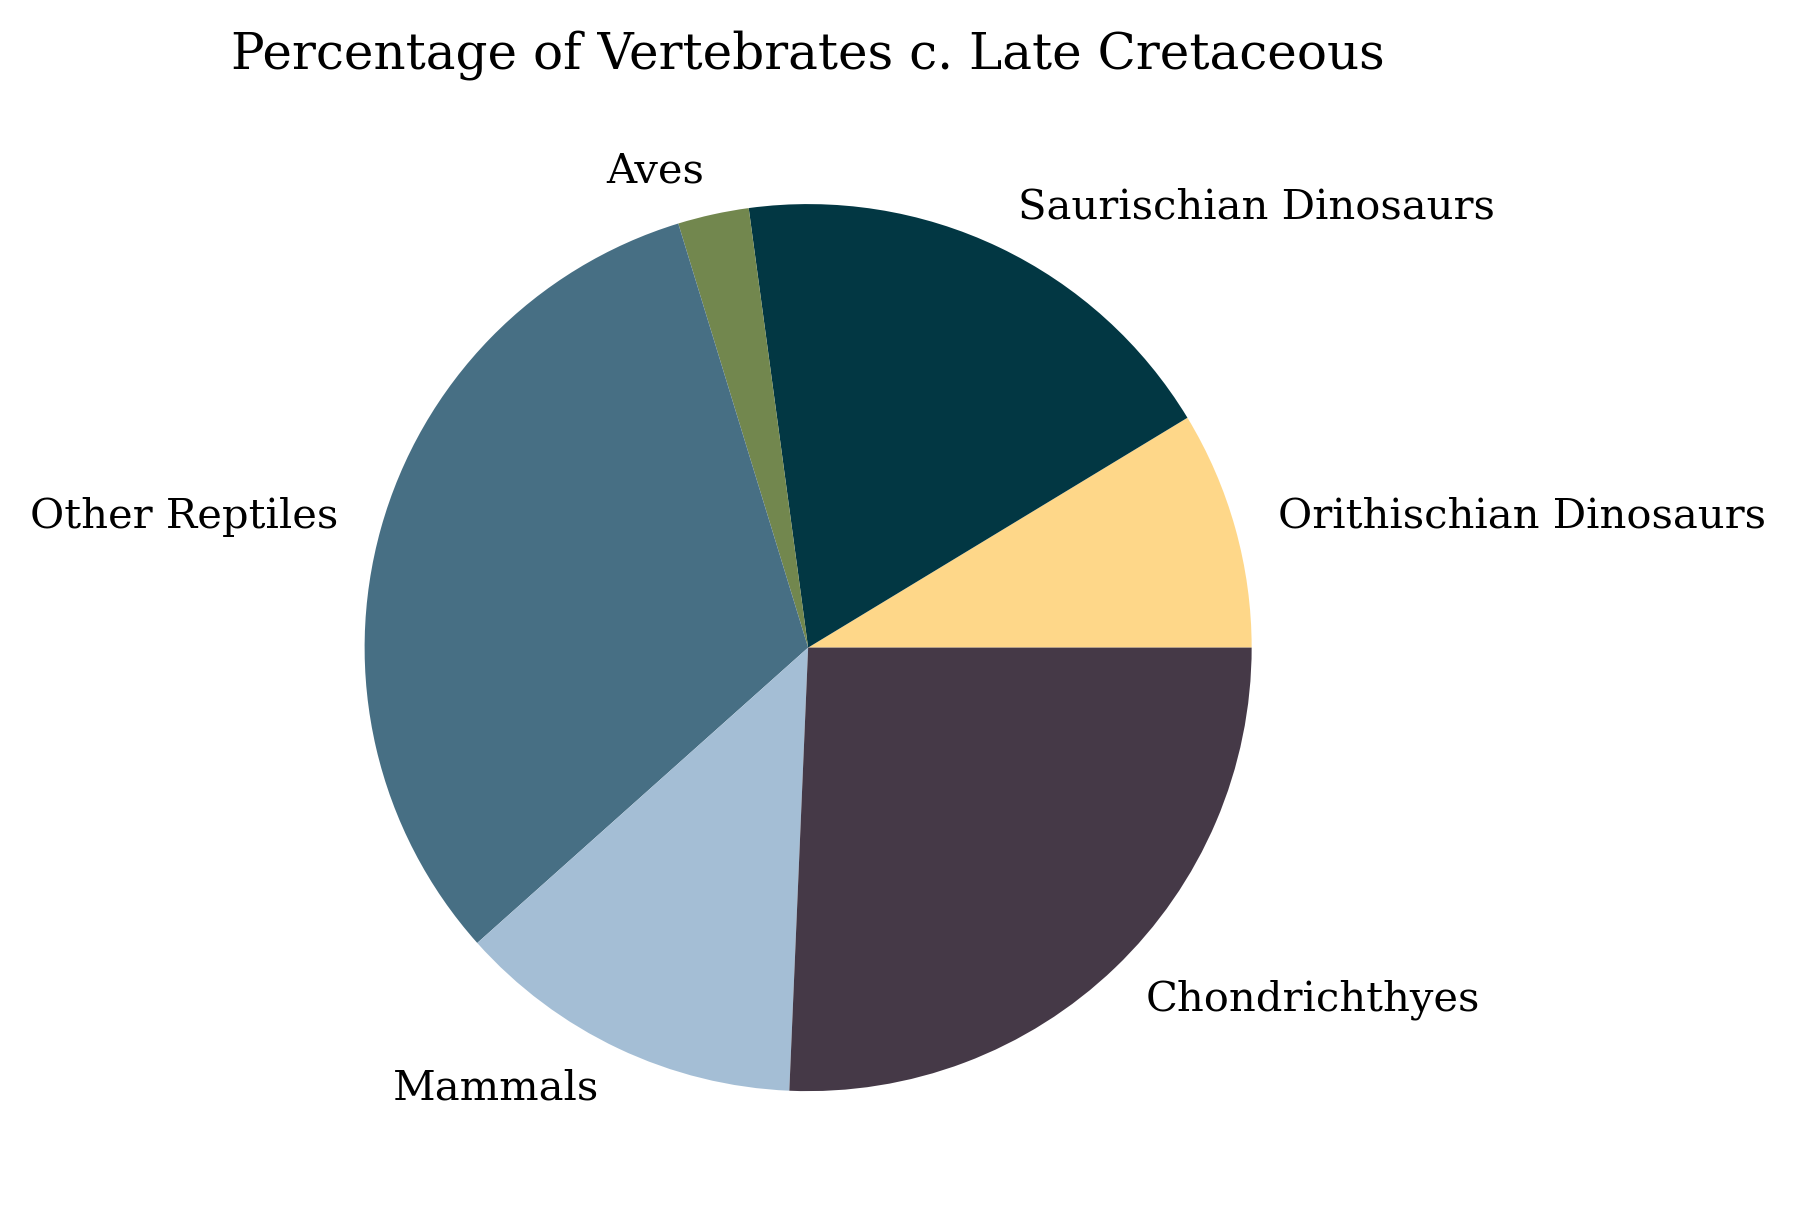

In [86]:
#labels = 'Birds (16.9%)', 'Reptiles (17%)', 'Fish (46%)', 'Mammals (9.3%)', 'Amphibians (11.3%)'

files = pd.read_csv('Data/Test - Sheet1.csv')
file_labels = files['name']

cmap = load_cmap("Acadia")
category_codes, unique_categories = pd.factorize(files["name"])
colors = [cmap(code) for code in category_codes]


# sizes = [16.9, 17, 46, 9.3, 11.3]

fig, ax = plt.subplots()
plt.title('Percentage of Vertebrates c. Late Cretaceous')

ax.pie(files['amount'], labels=file_labels, colors=colors)
plt.savefig('Figures/Piechart/lkp_vertebrate_pie_chart.png', bbox_inches='tight', dpi=300)

                             tarsus       ulna  cv.skull.1  second_digit  \
species                                                                    
Cinclodes_fuscus          34.950000  27.744220   34.770000      8.570000   
Aphrastura_spinicauda     24.360000  14.507143   25.360000      4.147670   
Pygarrhichas_albogularis  28.845000  22.136483   41.100000      5.754684   
Phrygilus_gayi            33.885343  25.492511   31.859759      7.850000   
Spindalis_zena            24.520000  22.516766   29.610000      6.012173   
...                             ...        ...         ...           ...   
Dendroica_caerulescens    25.320000  18.302954   27.350000      4.983263   
Dendroica_caerulescens    24.260000  16.580000   26.370000      4.740000   
Dendroica_striata         26.425000  17.840000   27.850000      5.263914   
Vermivora_peregrina       23.900000  16.110000   24.020000      4.691102   
Dendroica_tigrina         25.030000  17.563501   25.430000      4.906909   

           

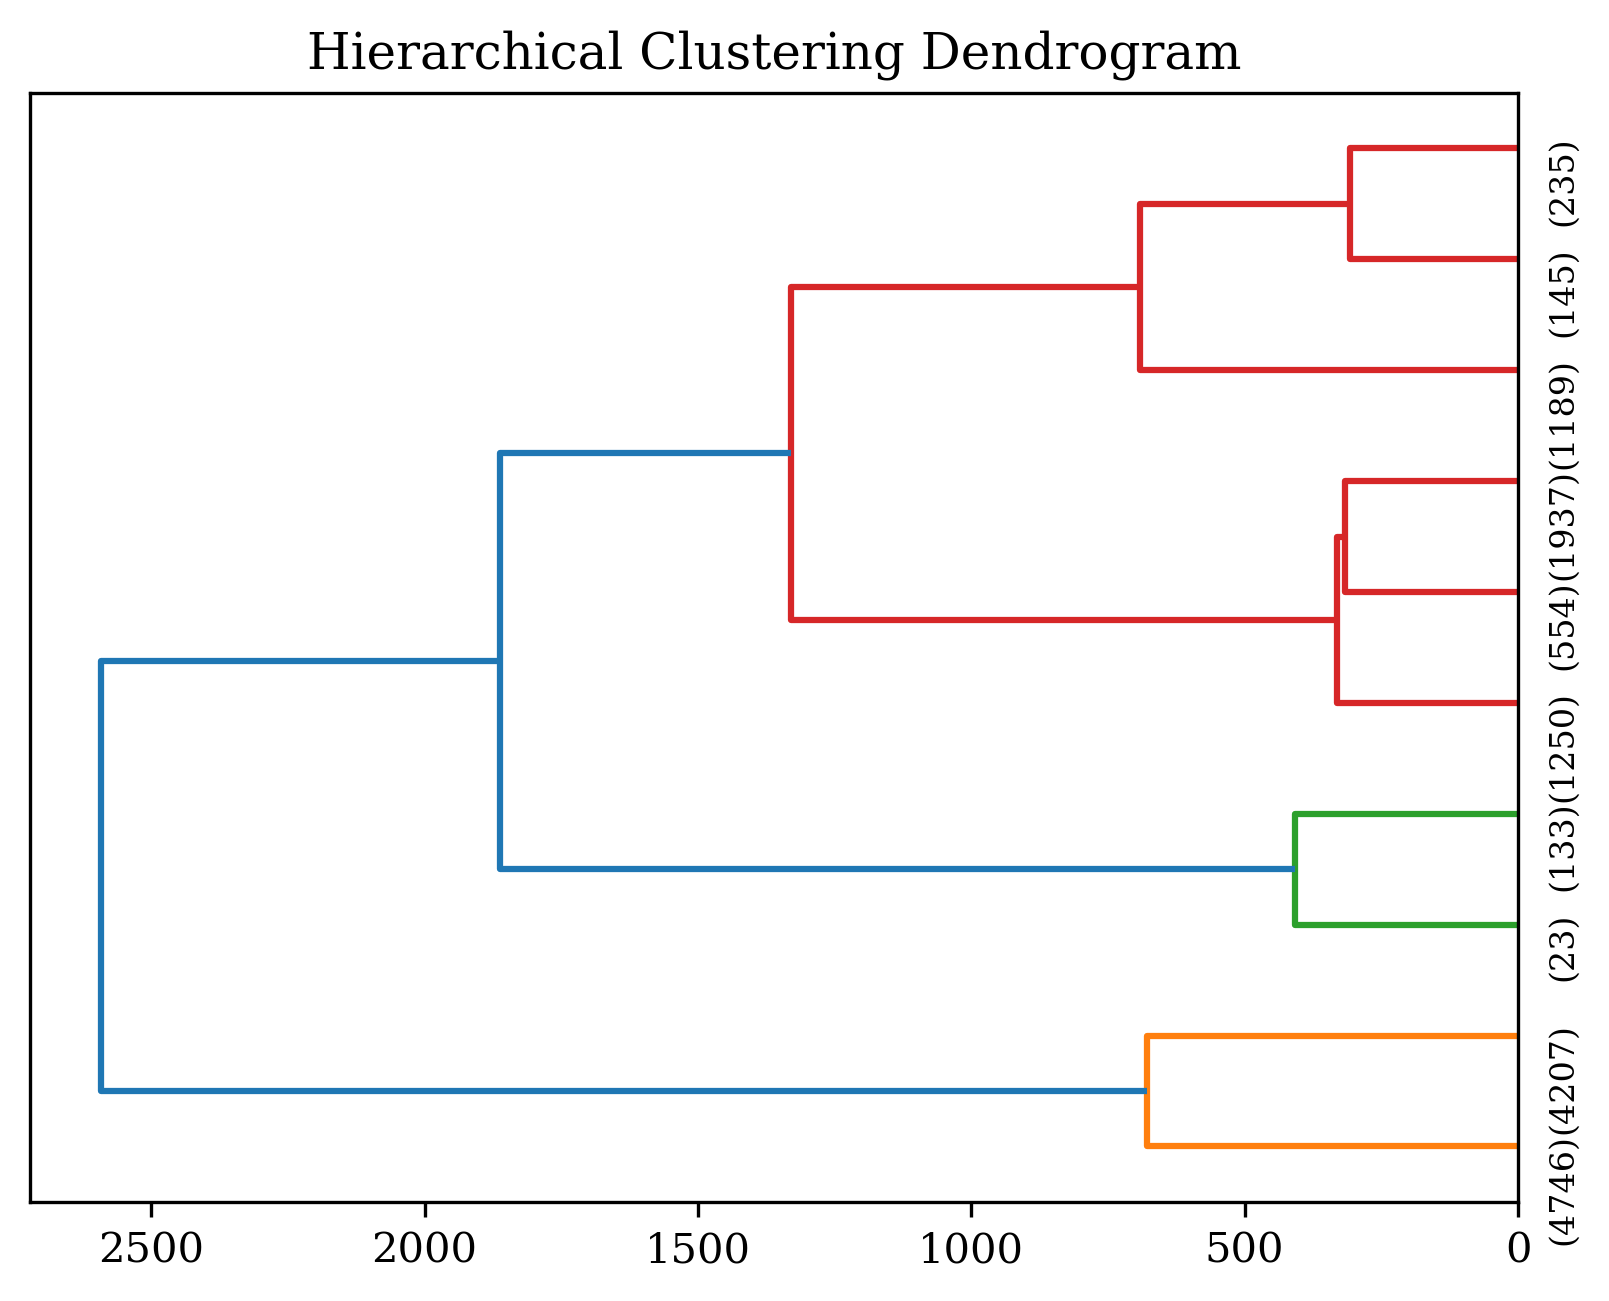

In [23]:
#
df = pd.read_csv("data/Complete_Trait_Dataset_v1.csv", usecols=range(1,12))
#data = np.loadtxt("Data/Complete_Trait_Dataset_v1.csv", delimiter=',', skiprows=1, usecols=range(1,12))
df = df.set_index('species')

print(df)

# Plot title
plt.title('Hierarchical Clustering Dendrogram')

# Calculate the distance between each sample
Z = linkage(df, 'ward')
 
# Plot with Custom leaves
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, labels=df.index, orientation='left', truncate_mode='lastp', p=10)

# Show the graph
plt.show()


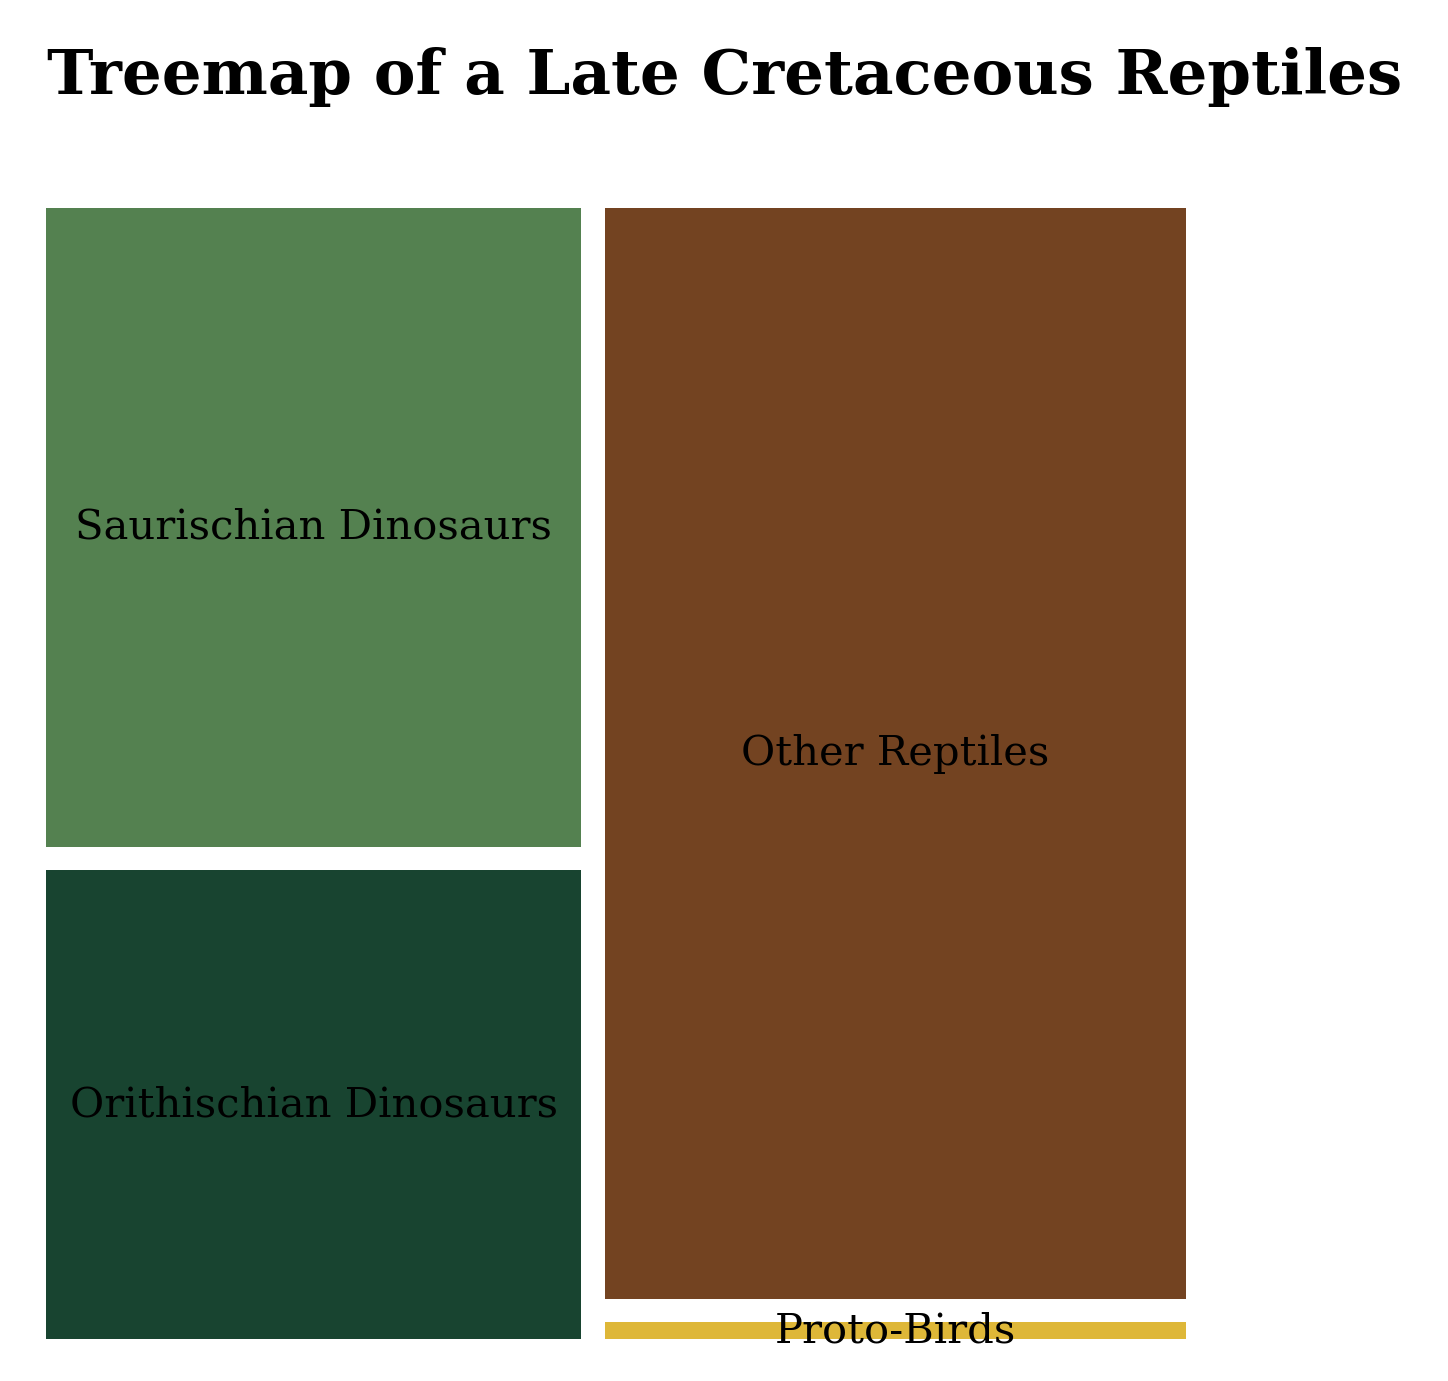

In [24]:
#libraries
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Nimbus Roman"]
df = pd.read_csv("data/Test - Sheet1.csv")


cmap = load_cmap("ClaudeMonet")
category_codes, unique_categories = pd.factorize(df["name"])
colors = [cmap(code) for code in category_codes]

text = """<Treemap of a Late Cretaceous Reptiles>
"""

# Change color
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_axis_off()
squarify.plot(
    sizes=df["amount"],
    label=df["name"],
    color=colors,
    text_kwargs={"color": "black", "fontsize": 10},
    pad=True,
    ax=ax,
)
fig_text(
    x=0.133,
    y=0.98,
    s=text,
    color="black",
    highlight_textprops=[
        {"fontsize": 15, "fontweight": "bold"},
    ],
    fontsize=10,
    ha="left",
)
# create a color palette
plt.savefig("Figures/Treemaps/Late Cretaceous Treemap.png", bbox_inches="tight", dpi=300)
# create a treemap
plt.axis('off')
plt.show()

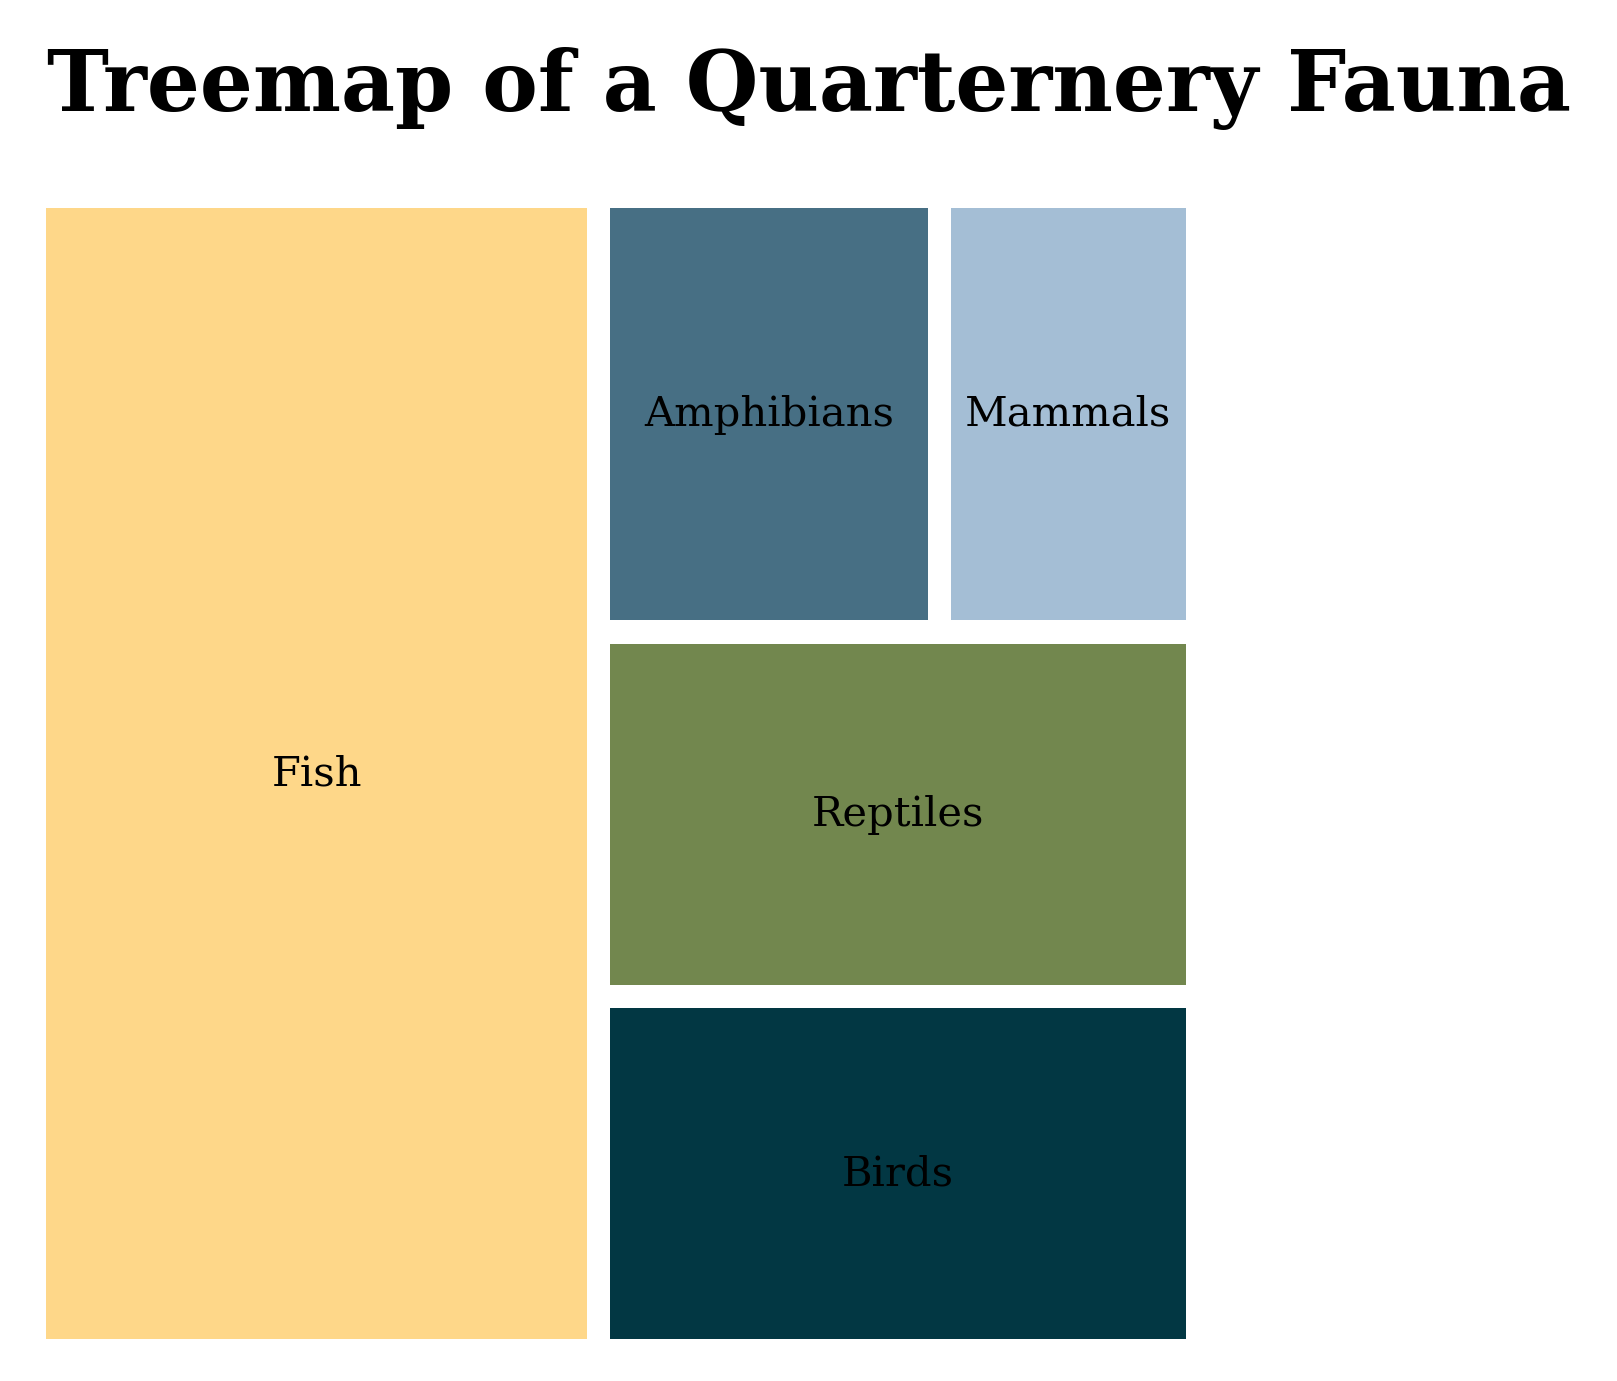

In [25]:
#libraries
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Nimbus Roman"]
df = pd.read_csv("data/Test - Sheet2.csv")


cmap = load_cmap("Acadia")
category_codes, unique_categories = pd.factorize(df["name"])
colors = [cmap(code) for code in category_codes]

text = """<Treemap of a Quarternery Fauna>
"""

# Change color
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_axis_off()
squarify.plot(
    sizes=df["amount"],
    label=df["name"],
    color=colors,
    text_kwargs={"color": "black", "fontsize": 10},
    pad=True,
    ax=ax,
)
fig_text(
    x=0.133,
    y=0.98,
    s=text,
    color="black",
    highlight_textprops=[
        {"fontsize": 20, "fontweight": "bold"},
    ],
    fontsize=14,
    ha="left",
)
# savefig
plt.savefig("Figures/Treemaps/Quarternery Treemap.png", bbox_inches='tight')
# create a treemap
plt.axis('off')
plt.show()